# 08 · EVT 적합도와 사건 간 의존을 반영한 불확실성

05 사건 목록과 **완료된 06 저장 모수**를 읽어 관측된 꼬리를 얼마나 설명하는지 확인합니다.
QQ·PP·밀도 그림과 관측 범위 내 초과비율은 다시 적합하지 않습니다.
세션(원래 CSV 파일) 부트스트랩에서만 **저장된 임계값을 고정하고** 모수를 다시 적합합니다.
사고기록이 없으므로 사고 예측 정확도나 이변량의 우위를 판정하지 않습니다.

**사용 순서:** 설정 → 입력·층 대조 → 적합도 → 실행시간 예측 → 부트스트랩 → 요약.
입력 ID는 직접 넣고 셀을 차례로 실행하세요. 결과는 새 `songdo_evt_validation/<RUN_ID>/`에만 저장합니다.
stable이 없거나 안정 후보가 없는 층은 이유를 기록하고 건너뜁니다. default12로 대신 채우지 않습니다.
신호 정보 부재, 같은 파일 안 의존, 파일 간 의존 가능성은 남아 있습니다.
0초 경계 값은 모형 외삽이며 관측 범위 안의 적합도와 별개입니다.

06에서 적용한 **TTC < 4초 또는 PET < 4초** 사전선별을 같은 함수와 설정으로 다시 적용합니다.
이는 일반적인 상호작용을 먼저 걸러내는 M1 PDF p.5·M2 PDF p.3의 절차입니다.
M1 좌회전 대 대향 직진 정의(M1 PDF p.5)에 맞춰, 어느 차량이든 진입·진출 접근로가 같은 유턴은
교차 M1 층에서 제외합니다. 새 상충 기준을 만드는 것이 아니라 원문의 대상과 절차를 적용합니다.
4초 사전선별과 12%·stable EVT 적합 임계값은 서로 다른 단계입니다.
그 뒤 교차 M1의 교점을 같은 04 아핀으로 Ortho 픽셀에 맞추고 `centre`만 남깁니다.
**목적 근거:** M1 PDF p.5, S06 PDF p.8·p.17, S01 PDF p.7의 교차로 대상·영역·먼 계산 문제.
**기하 근거:** 송도 공식 segmentation 차로 다각형과 README(중앙은 무라벨, Ortho는 픽셀, Local은 EPSG:5186 미터).
**구성 절차:** 선별 전 전체 M1 교점의 지점별 중앙값 방향으로 정지선 쪽 짧은 변을 고르고,
접근로별 최근접 Section의 변 끝점으로 볼록 껍질을 만듭니다. 이것은 **본 연구의 조작적 정의**이며
해당 구성 절차 문헌은 **not_found**입니다. 공간 조건을 원문에 실린 알고리즘으로 주장하지 않습니다.
차로 안 `on_lane`이 우선이며 중앙 밖 `outside_centre`도 제외합니다. 0.5m 경계 띠는 표시 전용이고
최신 v2 보완에 따라 포함·제외를 바꾸지 않습니다(해당 수치 문헌 not_found).
공간 함수 전체의 SHA256과 지도·04 아핀 입력 SHA256을 06 기록과 대조합니다.
`intersection_geometry/`의 모든 점은 선별 전 M1이고, 단계별 제외 표의 공간 수는 4초·유턴 제외 뒤입니다.
사전선별 전 실행 `20260924T160936Z_7cbe1a82`는 비교 참조이며 이 08의 검증 입력으로 쓸 수 없습니다.

## 1. 준비
표와 그림에 필요한 패키지를 불러옵니다. 이 셀은 자료를 읽거나 적합하지 않습니다.

In [1]:
from pathlib import Path
from datetime import datetime, timezone
import hashlib
import io
import json
import math
import re
import time
import uuid
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import LogFormatter
from scipy.optimize import minimize
from scipy.stats import genpareto, rankdata
from IPython.display import display
STATIONARY_MPS = 1.0 / 3.6  # 06의 우리 연구 선택. Fonod의 정지 기준이 아님.
SITES = list("ABCEFGHIJKLMNOPQRSTU")
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

## 2. 설정 — 분석 범위와 계산량을 정합니다
05·06 ID를 비워 두었습니다. 같은 입력을 사용한 완료 실행끼리 연결되어야 합니다.
사전선별 설정은 입력 06의 `run_metadata.json`에서 읽습니다. 08에서 따로 정하지 않습니다.
적합도는 선택한 모든 층에서 초과가 30개 이상일 때 그립니다(06의 충분성 기준).
부트스트랩 기본 대상은 각 유형·지표의 ALL과 초과가 가장 많은 지점 1곳입니다.
TTC와 PET의 상위 지점을 따로 고릅니다. 이변량은 두 주변 초과 수 중 작은 수로 고릅니다.
ξ≤−0.99, α≥0.999 또는 06 공분산 없음은 경계 추정으로 표시하고 기본 대상에서 뺍니다.
경계 추정 행은 기본 설정에서 QQ·PP·밀도·Pickands 적합도 그림도 생략하며, 상태표에 이유를 남깁니다.
`INCLUDE_BOUNDARY_ESTIMATES = True`로 포함해도 구간에는 “해석 불가(경계)”가 붙습니다.
이 수치는 모수 경계의 수치적 판별 설정이며 새로운 상충 기준이 아닙니다.
`BOOTSTRAP_SITES = None`, `TOP_SITE_COUNT = None`이면 충분한 지점 전체를 사용합니다.
특정 지점만 원하면 `BOOTSTRAP_SITES = ["ALL", "K"]`처럼 지정하세요.
B·지점 수는 계산 예산 설정이며 새로운 상충 판정 기준이 아닙니다.
실행시간 예측 셀까지 실행한 뒤 B·대상 범위를 바꾸려면 설정 이후부터 다시 실행하세요.

In [2]:
SOURCE05_ID = "20260924T125033Z_ffaaff43"
SOURCE06_ID = "20260924T191302Z_4491ed18"
PRESCREEN_SECONDS = None  # 입력 06에서 읽음: M1 PDF p.5, M2 PDF p.3.
EXCLUDE_UTURN_M1 = None  # 입력 06에서 읽음: M1 PDF p.5의 좌회전 정의, S06 PDF p.8 참고.
THRESHOLD_SETS = ["stable", "default12"]
KINDS = ["후미_기본", "교차_M1"]  # 다른 06 감도층도 추가 가능
B_UNIVARIATE = 300
B_BIVARIATE = 200
BOOTSTRAP_SITES = None
TOP_SITE_COUNT = 1
INCLUDE_BOUNDARY_ESTIMATES = False
BOUNDARY_XI = -0.99
BOUNDARY_ALPHA = 0.999
MIN_EXCEEDANCES = 30
LEVELS_SECONDS = [1.5, 1.0, 0.5]
RANDOM_SEED = 20260925
RUNTIME_TARGET_MINUTES = 30

## 3. 경로와 저장 규칙
입력은 읽기 전용입니다. 경로 이탈·기존 실행 덮어쓰기를 막고 읽은 파일의 SHA-256을 남깁니다.

In [3]:
def within(path, root):
    path, root = Path(path).resolve(), Path(root).resolve()
    if not path.is_relative_to(root):
        raise ValueError("허용 경로 밖입니다: " + str(path))
    return path


def run_input(project, family, run_id):
    if not isinstance(run_id, str) or not re.fullmatch(r"[A-Za-z0-9_-]+", run_id):
        raise ValueError("빈 입력 ID 또는 잘못된 입력 ID입니다.")
    parent = within(Path(project) / "data/processed" / family, Path(project) / "data/processed")
    return within(parent / run_id, parent)


def output_path(path):
    canonical = within(PROJECT / "data/processed/songdo_evt_validation", PROJECT / "data/processed")
    run = within(RUN_DIR, canonical)
    if run.parent != canonical or run.name != RUN_ID:
        raise ValueError("이번 실행 결과 폴더가 아닙니다.")
    return within(path, run)


def save_csv(table, name):
    target = output_path(RUN_DIR / name)
    target.parent.mkdir(parents=True, exist_ok=True)
    tmp = output_path(target.with_name(target.name + ".tmp"))
    table.to_csv(tmp, index=False, encoding="utf-8-sig")
    tmp.replace(target)


def save_json(value, name):
    target = output_path(RUN_DIR / name)
    target.parent.mkdir(parents=True, exist_ok=True)
    tmp = output_path(target.with_name(target.name + ".tmp"))
    tmp.write_text(json.dumps(value, ensure_ascii=False, indent=2, default=str), encoding="utf-8")
    tmp.replace(target)


def read_input(path):
    path = Path(path).resolve()
    if not any(path.is_relative_to(p.resolve()) for p in (SOURCE05, SOURCE06)):
        raise ValueError("05·06 실행 결과 밖은 읽지 않습니다.")
    before = path.stat()
    content = path.read_bytes()
    after = path.stat()
    if (before.st_size, before.st_mtime_ns) != (after.st_size, after.st_mtime_ns):
        raise ValueError("읽는 동안 입력 파일이 바뀌었습니다: " + str(path))
    INPUT_MANIFEST[str(path.relative_to(PROJECT))] = {
        "size": after.st_size, "mtime_ns": after.st_mtime_ns,
        "sha256": hashlib.sha256(content).hexdigest()}
    if path.suffix == ".json":
        return json.loads(content.decode("utf-8-sig"))
    return pd.read_csv(io.BytesIO(content), dtype={"site": "str", "file_stem": "str", "drone_id": "str"})


def load_threshold_sets(source, requested, reader=pd.read_csv):
    uni, bi, records = {}, {}, []
    if not requested or len(set(requested)) != len(requested):
        raise ValueError("THRESHOLD_SETS는 중복 없는 비어 있지 않은 목록이어야 합니다.")
    for name in requested:
        if name not in {"stable", "default12"}:
            raise ValueError("지원하지 않는 임계값 기준: " + str(name))
        for family, store in (("univariate_gpd", uni), ("bivariate_logistic_gp", bi)):
            path = Path(source) / f"{family}_{name}.csv"
            compatibility = False
            if name == "default12" and not path.is_file():
                path = Path(source) / f"{family}.csv"
                compatibility = True
            if not path.is_file():
                records.append(dict(threshold_set=name, family=family, status="missing_set", file=str(path)))
                continue
            table = reader(path)
            keys = ["유형", "지점"] + (["지표"] if family == "univariate_gpd" else [])
            required = set(keys) | {"fit", "hours"}
            required |= {"n", "threshold"} if family == "univariate_gpd" else {"n_pairs"}
            if not required.issubset(table.columns) or table.duplicated(keys).any():
                raise ValueError("06 결과의 필수 열 누락 또는 중복 키: " + str(path))
            if "threshold_set" in table and not table["threshold_set"].eq(name).all():
                raise ValueError("파일 이름과 threshold_set이 다릅니다: " + str(path))
            store[name] = table
            records.append(dict(threshold_set=name, family=family, status="compatibility" if compatibility else "loaded", file=str(path)))
    return uni, bi, pd.DataFrame(records)


def prepare_sessions(progress):
    required = {"site", "file_stem", "status", "observed_union_s", "jitter_flag_s"}
    if not required.issubset(progress):
        raise ValueError("progress 파일에 필요한 파일별 관측시간 열이 없습니다.")
    if not progress["status"].eq("completed").all():
        raise ValueError("미완료 또는 실패한 05 파일이 있습니다.")
    sessions = progress.copy()
    if sessions[["site", "file_stem"]].isna().any().any() or sessions.duplicated(["site", "file_stem"]).any():
        raise ValueError("완료 파일의 식별자가 누락되었거나 중복됩니다.")
    union = pd.to_numeric(sessions["observed_union_s"], errors="coerce")
    jitter = pd.to_numeric(sessions["jitter_flag_s"], errors="coerce")
    if (~np.isfinite(union) | ~np.isfinite(jitter) | (union < 0) | (jitter < 0) | (jitter > union)).any():
        raise ValueError("파일별 관측시간 또는 떨림 시간이 유효하지 않습니다.")
    sessions["hours"] = (union - jitter) / 3600.0
    sessions["session_key"] = sessions["site"].astype(str) + "|" + sessions["file_stem"].astype(str)
    return sessions.reset_index(drop=True)


def load_literature_settings(metadata):
    procedure = metadata.get("literature_procedure")
    if not isinstance(procedure, dict) or not isinstance(procedure.get("settings"), dict):
        raise ValueError("06에 문헌 사전선별 설정이 없습니다. 사전선별 절차를 적용해 완료한 새 06 실행을 입력하세요.")
    settings = procedure["settings"]
    seconds = settings.get("PRESCREEN_SECONDS")
    exclude = settings.get("EXCLUDE_UTURN_M1")
    if (isinstance(seconds, bool) or not isinstance(seconds, (int, float))
            or not np.isfinite(seconds) or seconds <= 0 or not isinstance(exclude, bool)):
        raise ValueError("06의 문헌 사전선별 설정이 유효하지 않습니다.")
    expected = SOURCE06_FUNCTION_SHA256["literature_prescreen"]
    if procedure.get("function_sha256") != expected:
        raise ValueError("06·08 literature_prescreen 함수 SHA-256이 다릅니다. 같은 버전의 노트북을 사용하세요.")
    return float(seconds), exclude


def load_spatial_settings(metadata):
    procedure = metadata.get("literature_procedure")
    spatial = procedure.get("spatial") if isinstance(procedure, dict) else None
    if not isinstance(spatial, dict) or spatial.get("version") != "stop_line_hull_v2":
        raise ValueError("06에 v2 공간 절차 기록이 없습니다. 같은 버전의 06을 사용하세요.")
    expected = {name: value for name, value in SOURCE06_FUNCTION_SHA256.items() if name.startswith("spatial_")}
    if spatial.get("function_sha256") != expected:
        raise ValueError("06·08 공간 함수 SHA-256이 다릅니다.")
    geometry_id = spatial.get("geometry_id")
    if not isinstance(geometry_id, str) or not geometry_id or Path(geometry_id).name != geometry_id or geometry_id in (".", ".."):
        raise ValueError("06 공간 지도 실행 ID가 유효하지 않습니다.")
    if spatial.get("boundary_affects_selection") is not False or spatial.get("boundary_display_m") != 0.5:
        raise ValueError("06 공간 경계 표시 계약이 다릅니다.")
    return geometry_id

## 4. 06의 사전선별·지표 변환 복사
`literature_prescreen`, `as_negated`와 확률·우도 함수를 같은 작업의 06에서 텍스트 그대로 복사했습니다. 사전선별 함수 지문은 입력 06의 실행 기록과 대조하고, 모든 복사 함수 지문을 결과에 기록합니다.

In [4]:
SOURCE06_FUNCTION_SHA256 = {'literature_prescreen': '08000d82d5f741c186d7fbaec7b7e2f220ab728c7ac2717f408ba4ead780c060', 'as_negated': 'c797367bc0741e927ba5eefb338f3d22314d0e2161326b47349e7508d8236d91', 'gpd_nll': 'dca37f8b8db9f7be61f59380385cc88e1f57a6129c2ee4ecf192082d67cd9e8d', 'conditional_boundary_prob': '236f044e08aad3cb62d37567028fe1329f8165a6483cb5ebd58202c12a4acdaa', 'margin_terms': '1b6ab962b4902bd9bb0f2069f4b37dfcd2d6277cfeff673d11966a9795a5cb53', 'unpack': '79628bd3d71a9256dc0cac16f14334a7fece6780aece68fc08c09fd1f89ba1b3', 'bgp_nll': '5af5f24037dc2327a580fa830fc5cb44d827d2b4ba4bf2e557a6fd6ee6fba487', 'boundary_z': '3750573c4ed2172de034b06bf056e51cfe654e0bfd47c6aa0a5c03471da87362', 'bgp_boundary': '0e9040de92a56ced1100e461a52206388985bcf1b8fc800ef163391692829171', 'spatial_affine': 'e8c8741f598b653da41200d1219010f8f11753d716df6a2cd15b969bff6a3212', 'spatial_centre_polygon': 'df1d35c90810ef7499e20c070cef9e7e27d2770a7bd77186021325639dcc43ec', 'spatial_classify': 'cd4f69f0e288f8c119a526c6adaefa8bec2a24fbc0172660af87378c0823563b', 'spatial_boundary_distance': '34055d016d4b87479d9b1ad5fd50289743aa6da79083b6618e302032d216a4c8', 'spatial_prepare': 'ad3475b82567ebe3d1893b0f96e45933b64cf8a60fe06ce0cbc807d70947102b', 'spatial_filter': '9df7ba9ae91d14b88658dbb5fe4db6909252ac64aace36257100307f451e4463', 'spatial_save': '90f46864de0e00ae3b6cad0a7ed05a2aafee89e8e9a536b2ca90c04a793ddc93'}

def literature_prescreen(rear, cross):
    """사건 단위 4초 OR 선별 후 M1 유턴만 제외; 입력과 지표 값은 보존한다."""
    if (isinstance(PRESCREEN_SECONDS, (bool, np.bool_))
            or not np.isfinite(PRESCREEN_SECONDS) or PRESCREEN_SECONDS <= 0):
        raise ValueError("PRESCREEN_SECONDS는 양의 유한한 초 값이어야 합니다.")
    if not isinstance(EXCLUDE_UTURN_M1, (bool, np.bool_)):
        raise ValueError("EXCLUDE_UTURN_M1은 True/False여야 합니다.")

    def selected(table, pet_column):
        ttc = pd.to_numeric(table["min_ttc_s"], errors="coerce")
        pet = pd.to_numeric(table[pet_column], errors="coerce")
        return ((np.isfinite(ttc) & ttc.lt(PRESCREEN_SECONDS))
                | (np.isfinite(pet) & pet.lt(PRESCREEN_SECONDS))).fillna(False)

    rear_keep = selected(rear, "min_pet_s")
    cross_keep = selected(cross, "pet_s")
    m1 = cross["m1_left_turn_opposing_through"].astype(str).str.lower().eq("true")
    uturn = pd.Series(False, index=cross.index)
    invalid_flows = pd.Series(0, index=cross.index, dtype="int64")
    for column in ("flow_a", "flow_b"):
        flow = (cross[column] if column in cross else pd.Series(pd.NA, index=cross.index))
        parts = flow.astype("string").str.extract(r"^\s*([0-9]+)_[0-9]+\s*→\s*([0-9]+)_[0-9]+\s*$")
        valid = parts.notna().all(axis=1)
        same = parts[0].str.lstrip("0").eq(parts[1].str.lstrip("0")).fillna(False)
        uturn |= valid & same
        invalid_flows += (~valid).astype("int64")
    removed_uturn = cross_keep & m1 & uturn & EXCLUDE_UTURN_M1
    rows = []
    groups = [
        (["후미_기본", "후미_기본_엄격", "후미_기본_2DTTC"], rear,
         rear["lane_role"].eq("through_or_shared"), rear_keep, False),
        (["후미_전차로"], rear, pd.Series(True, index=rear.index), rear_keep, False),
        (["교차_M1", "교차_M1_엄격"], cross, m1, cross_keep, True),
    ]
    for names, table, membership, keep, is_cross in groups:
        for site in ["ALL", *sorted(table.loc[membership, "site"].dropna().unique())]:
            before = membership if site == "ALL" else membership & table["site"].eq(site)
            after_screen = before & keep
            removed = int((after_screen & removed_uturn).sum()) if is_cross else 0
            audit = {"지점": site, "선별전_사건": int(before.sum()),
                     "사전선별_제외": int((before & ~keep).sum()),
                     "사전선별후_사건": int(after_screen.sum()), "유턴_제외": removed,
                     "유턴판정불가_사건": int((after_screen & invalid_flows.gt(0)).sum()) if is_cross else 0,
                     "유턴판정불가_흐름": int(invalid_flows.loc[after_screen].sum()) if is_cross else 0,
                     "선별후_사건": int(after_screen.sum()) - removed}
            rows.extend({"유형": name, **audit} for name in names)
    return rear.loc[rear_keep].copy(), cross.loc[cross_keep & ~removed_uturn].copy(), pd.DataFrame(rows)

def as_negated(table, ttc_col, pet_col, strict=False, speed_cols=None, ttc_status="ttc_status", types=None,
               ttc_jitter="jitter_ttc"):
    ttc = pd.to_numeric(table[ttc_col], errors="coerce")
    pet = pd.to_numeric(table[pet_col], errors="coerce")
    jitter_x_removed = table[ttc_status].eq("computed") & np.isfinite(ttc) & table[ttc_jitter]
    jitter_y_removed = table["pet_status"].eq("computed") & np.isfinite(pet) & table["jitter_pet"]
    eligible_x = ~table[ttc_jitter]
    eligible_y = ~table["jitter_pet"]
    ok_x = table[ttc_status].eq("computed") & eligible_x
    ok_y = table["pet_status"].eq("computed") & eligible_y
    lane_change = pd.Series(False, index=table.index)
    if types is not None:
        lc_x = table[types[0]].eq("lane_change")
        lc_y = table[types[1]].eq("lane_change")
        lane_change = (lc_x & ok_x) | (lc_y & ok_y)
        ok_x &= ~lc_x
        ok_y &= ~lc_y
        eligible_x &= ~lc_x
        eligible_y &= ~lc_y
    base_x, base_y = ok_x.copy(), ok_y.copy()
    moto = table["motorcycle_involved"]
    stopped_x = stopped_y = pd.Series(False, index=table.index)
    if strict:
        ok_x &= ~moto
        ok_y &= ~moto
        eligible_x &= ~moto
        eligible_y &= ~moto
        if speed_cols is not None:
            stopped_x = pd.to_numeric(table[speed_cols[0]], errors="coerce") < STATIONARY_MPS
            stopped_y = pd.to_numeric(table[speed_cols[1]], errors="coerce") < STATIONARY_MPS
            ok_x &= ~stopped_x
            ok_y &= ~stopped_y
            eligible_x &= ~stopped_x
            eligible_y &= ~stopped_y
    x = np.where(ok_x, -ttc, np.nan)
    y = np.where(ok_y, -pet, np.nan)
    ttc_overlap = table[ttc_status].eq("body_overlap")
    pet_overlap = table["pet_status"].eq("body_overlap")
    usable_before = base_x | base_y
    return pd.DataFrame({"site": table["site"].to_numpy(), "x": x, "y": y,
                         "body_overlap": (ttc_overlap | pet_overlap).to_numpy(),
                         "x_overlap": np.where(ttc_overlap & eligible_x, -ttc, np.nan),
                         "y_overlap": np.where(pet_overlap & eligible_y, -pet, np.nan),
                         "jitter_ttc_removed": jitter_x_removed.to_numpy(),
                         "jitter_pet_removed": jitter_y_removed.to_numpy(),
                         "lane_change_removed": lane_change.to_numpy(),
                         "moto_removed": (moto & strict & usable_before).to_numpy(),
                         "stopped_removed": (((stopped_x & base_x) | (stopped_y & base_y)) & ~(moto & strict)).to_numpy()})

def gpd_nll(params, z):
    log_sigma, xi = params
    if xi <= -1.0:
        return np.inf
    sigma = math.exp(log_sigma)
    if abs(xi) < 1e-8:
        return len(z) * log_sigma + z.sum() / sigma
    t = 1.0 + xi * z / sigma
    if np.any(t <= 0):
        return np.inf
    return len(z) * log_sigma + (1.0 + 1.0 / xi) * np.log(t).sum()

def conditional_boundary_prob(u, sigma, xi, level=0.0):
    z = level - u
    if abs(xi) < 1e-8:
        return math.exp(-z / sigma)
    t = 1.0 + xi * z / sigma
    return 0.0 if t <= 0 else t ** (-1.0 / xi)

def margin_terms(values, u, sigma, xi, zeta):
    exceed = values > u
    z = np.full(len(values), -1.0 / math.log1p(-zeta))
    log_dz = np.zeros(len(values))
    if exceed.any():
        w = values[exceed] - u
        if abs(xi) < 1e-8:
            tail = zeta * np.exp(-w / sigma)
            dens = zeta / sigma * np.exp(-w / sigma)
        else:
            t = 1.0 + xi * w / sigma
            if np.any(t <= 0):
                return None
            tail = zeta * t ** (-1.0 / xi)
            dens = zeta / sigma * t ** (-1.0 / xi - 1.0)
        if np.any(tail >= 1) or np.any(tail <= 0):
            return None
        log_f = np.log1p(-tail)
        z_ex = -1.0 / log_f
        z[exceed] = z_ex
        log_dz[exceed] = 2.0 * np.log(z_ex) + np.log(dens) - log_f
    return z, log_dz, exceed

def unpack(theta):
    if theta[4] >= 0:
        alpha = 1.0 / (1.0 + math.exp(-theta[4]))
    else:
        exp_theta = math.exp(theta[4])
        alpha = exp_theta / (1.0 + exp_theta)
    return (math.exp(theta[0]), theta[1], math.exp(theta[2]), theta[3], alpha)

def bgp_nll(theta, x, y, ux, uy, zeta_x, zeta_y):
    sx, xx, sy, xy, a = unpack(theta)
    if xx <= -1.0 or xy <= -1.0 or a <= 0.0:
        return np.inf
    mx = margin_terms(x, ux, sx, xx, zeta_x)
    my = margin_terms(y, uy, sy, xy, zeta_y)
    if mx is None or my is None:
        return np.inf
    z1, ld1, e1 = mx
    z2, ld2, e2 = my
    lz1, lz2 = np.log(z1), np.log(z2)
    lp1, lp2 = -lz1 / a, -lz2 / a
    ls = np.logaddexp(lp1, lp2)
    lv = a * ls
    # Logarithms of -V_1, -V_2 and -V_12; avoid intermediate powers.
    lv1 = lp1 - ls + lv - lz1
    lv2 = lp2 - ls + lv - lz2
    lv12 = ((math.log1p(-a) - math.log(a)) if a < 1.0 else -np.inf) + lp1 - ls + lp2 - ls + lv - lz1 - lz2
    ll = -np.exp(lv)
    r10, r01, r11 = e1 & ~e2, ~e1 & e2, e1 & e2
    with np.errstate(divide="ignore", invalid="ignore"):
        ll = ll + np.where(r10, lv1 + ld1, 0.0)
        ll = ll + np.where(r01, lv2 + ld2, 0.0)
        ll = ll + np.where(r11, np.logaddexp(lv1 + lv2, lv12) + ld1 + ld2, 0.0)
    total = ll.sum()
    return -total if np.isfinite(total) else np.inf

def boundary_z(u, sigma, xi, zeta):
    tail = zeta * conditional_boundary_prob(u, sigma, xi)
    if tail <= 0:
        return np.inf, 0.0
    if tail >= 1:
        return 0.0, 1.0
    return -1.0 / math.log1p(-tail), tail

def bgp_boundary(theta, ux, uy, zeta_x, zeta_y):
    sx, xx, sy, xy, a = unpack(theta)
    if a <= 0.0:  # The logistic can underflow to 0; it is outside the model domain.
        return np.nan, np.nan, np.nan, np.nan
    z1, p_x = boundary_z(ux, sx, xx, zeta_x)
    z2, p_y = boundary_z(uy, sy, xy, zeta_y)
    if z1 == 0.0 or z2 == 0.0:
        return 1.0, p_x, p_y, 1.0 - (1.0 - p_x) * (1.0 - p_y)
    log_v = a * np.logaddexp(-math.log(z1) / a, -math.log(z2) / a)
    p_or = -math.expm1(-math.exp(log_v))
    p_ind = -math.expm1(math.log1p(-p_x) + math.log1p(-p_y))
    return p_or, p_x, p_y, p_ind

def spatial_affine(row):
    """07과 같은 EPSG 미터 = A @ Ortho 픽셀 + b 검사와 변환 계약."""
    a = np.array([[row["hand_a11"], row["hand_a12"]], [row["hand_a21"], row["hand_a22"]]], float)
    b = np.array([row["hand_b1"], row["hand_b2"]], float)
    if not np.isfinite(a).all() or not np.isfinite(b).all() or np.linalg.cond(a) > 1e8:
        raise ValueError("유효한 04 아핀 계수가 없습니다.")
    if row["status"] != "completed" or row["hand_local_frame"] != "right_handed":
        raise ValueError("04 완료 상태 또는 EPSG 오른손 좌표계가 확인되지 않았습니다.")
    if not np.isclose(np.linalg.det(a), float(row["hand_det"]), rtol=1e-5, atol=1e-12):
        raise ValueError("04 요약표와 아핀 계수의 행렬식이 다릅니다.")
    return a, b

def spatial_centre_polygon(lanes, anchor):
    """공식 차로의 정지선 쪽 짧은 변 → 접근로별 최근접 Section → 볼록 껍질.

    본 연구의 조작적 정의이며 이 구성 절차 자체의 문헌 근거는 not_found.
    polygon_valid=False도 좌표가 유한하면 사용한다(10 MD 144행).
    """
    from scipy.spatial import ConvexHull, QhullError
    columns = ["tlx", "tly", "blx", "bly", "brx", "bry", "trx", "try"]
    quads, by_section = [], {}
    for row in lanes.to_dict("records"):
        q = np.asarray([row[c] for c in columns], float).reshape(4, 2)
        if not np.isfinite(q).all():
            continue
        quads.append(q)
        if not np.isfinite(anchor).all():
            continue
        section = str(row["Section"])
        approach = section.split("_")[0]
        if not approach.isdigit():
            raise ValueError("접근로 번호를 해석할 수 없는 Section: " + section)
        edges = [(q[i], q[(i + 1) % 4]) for i in range(4)]
        edges.sort(key=lambda e: np.linalg.norm(e[0] - e[1]))
        edge = min(edges[:2], key=lambda e: np.linalg.norm((e[0] + e[1]) / 2 - anchor))
        distance = float(np.linalg.norm((edge[0] + edge[1]) / 2 - anchor))
        by_section.setdefault(section, []).append((distance, edge, str(row["Lane"])))
    best = {}
    for section, edges in by_section.items():
        approach = section.split("_")[0]
        distance = min(e[0] for e in edges)
        if approach not in best or distance < best[approach][0]:
            best[approach] = (distance, section)
    endpoints, used = [], []
    for approach, (distance, section) in best.items():
        for _, edge, lane in by_section[section]:
            endpoints.extend(edge)
            used.append({"approach": approach, "Section": section, "Lane": lane,
                         "section_min_distance_px": distance,
                         "edge_x1": float(edge[0][0]), "edge_y1": float(edge[0][1]),
                         "edge_x2": float(edge[1][0]), "edge_y2": float(edge[1][1])})
    points = np.asarray(endpoints, float).reshape(-1, 2)
    hull, status = np.empty((0, 2)), "insufficient_centre_vertices"
    if len(points) >= 3:
        try:
            hull = points[ConvexHull(points).vertices]
            status = "ok"
        except QhullError:
            status = "degenerate_centre_polygon"
    if not np.isfinite(anchor).all():
        status = "no_finite_m1_anchor"
    return {"quads": quads, "hull": hull, "sections": used, "status": status,
            "anchor": np.asarray(anchor, float)}

def spatial_classify(xy, geometry):
    """최신 SPEC: on_lane 우선, 다음 centre, 나머지 outside_centre. 경계 띠로 변경하지 않음."""
    from matplotlib.path import Path as PolygonPath
    xy = np.asarray(xy, float).reshape(-1, 2)
    result = np.full(len(xy), "invalid_conflict_point", dtype=object)
    valid = np.isfinite(xy).all(axis=1)
    if geometry["status"] != "ok":
        result[valid] = geometry["status"]
        return result
    on_lane = np.zeros(len(xy), bool)
    for quad in geometry["quads"]:
        on_lane |= PolygonPath(quad).contains_points(xy)
    in_centre = PolygonPath(geometry["hull"]).contains_points(xy)
    result[valid] = np.where(on_lane[valid], "on_lane", np.where(in_centre[valid], "centre", "outside_centre"))
    return result

def spatial_boundary_distance(xy, polygons, affine):
    """점과 다각형 변을 같은 04 선형변환으로 미터화. 0.5m는 표시 전용."""
    xy = np.asarray(xy, float).reshape(-1, 2) @ affine.T
    distance = np.full(len(xy), np.inf)
    for polygon in polygons:
        polygon = np.asarray(polygon, float) @ affine.T
        for first, last in zip(polygon, np.roll(polygon, -1, axis=0)):
            delta = last - first
            length2 = float(delta @ delta)
            t = np.zeros(len(xy)) if length2 == 0 else np.clip((xy - first) @ delta / length2, 0, 1)
            distance = np.minimum(distance, np.linalg.norm(xy - (first + t[:, None] * delta), axis=1))
    distance[~np.isfinite(distance)] = np.nan
    return distance

def spatial_prepare(cross, source04, geometry_dir):
    """사전선별 전 전체 M1의 지점별 중앙값을 방향 기준으로 고정한다(시험 원형과 동일)."""
    from pathlib import Path
    import hashlib
    source04, geometry_dir = Path(source04), Path(geometry_dir)
    paths = {"handedness": source04 / "coordinate_handedness_by_file.csv",
             "affine_progress": source04 / "progress.csv", "map_index": geometry_dir / "map_index.csv"}
    provenance = {key: {"path": str(path), "sha256": hashlib.sha256(path.read_bytes()).hexdigest()}
                  for key, path in paths.items()}
    hand, progress, lanes = (pd.read_csv(paths[key]) for key in ("handedness", "affine_progress", "map_index"))
    coefficients = ["hand_a11", "hand_a12", "hand_a21", "hand_a22", "hand_b1", "hand_b2"]
    affines = hand.merge(progress[["source_file", "status"] + coefficients], on="source_file",
                         how="left", validate="one_to_one")
    if affines["file_stem"].duplicated().any():
        raise ValueError("04 아핀 file_stem 중복")
    affines = affines.set_index("file_stem")
    required = {"site", "file_stem", "conflict_x", "conflict_y", "m1_left_turn_opposing_through"}
    if not required.issubset(cross.columns):
        raise ValueError("공간 조건 입력 열 누락: " + str(sorted(required - set(cross.columns))))
    m1 = cross["m1_left_turn_opposing_through"].astype(str).str.lower().eq("true").to_numpy()
    records = cross.loc[m1].copy().reset_index(drop=True)
    records.insert(0, "catalog_row", np.flatnonzero(m1) + 1)  # 07 manifest와 같은 1-based 행
    xy = np.full((len(records), 2), np.nan)
    matrices = {}
    for stem, indices in records.groupby("file_stem", dropna=False).groups.items():
        if stem not in affines.index:
            raise ValueError("04 아핀 파일 미확인: " + str(stem))
        row = affines.loc[stem]
        if not records.loc[indices, "site"].eq(row["site"]).all():
            raise ValueError("05 사건과 04 아핀의 지점 불일치: " + str(stem))
        a, b = spatial_affine(row)
        matrices[stem] = a
        local = records.loc[indices, ["conflict_x", "conflict_y"]].apply(pd.to_numeric, errors="coerce").to_numpy(float)
        xy[indices] = np.linalg.solve(a, (local - b).T).T
    records["ortho_x"], records["ortho_y"] = xy[:, 0], xy[:, 1]
    records["spatial_class"] = "unclassified"
    records["boundary_distance_m"] = np.nan
    geometries, section_rows, vertex_rows, site_rows = {}, [], [], []
    sites = sorted(set(lanes["site"].dropna()) | set(records["site"].dropna()))
    for site in sites:
        indices = records.index[records["site"].eq(site)]
        points = xy[indices]
        finite = points[np.isfinite(points).all(axis=1)]
        anchor = np.median(finite, axis=0) if len(finite) else np.array([np.nan, np.nan])
        geometry = spatial_centre_polygon(lanes.loc[lanes["site"].eq(site)], anchor)
        geometries[site] = geometry
        records.loc[indices, "spatial_class"] = spatial_classify(points, geometry)
        for stem, group in records.loc[indices].groupby("file_stem"):
            records.loc[group.index, "boundary_distance_m"] = spatial_boundary_distance(
                xy[group.index], [*geometry["quads"], geometry["hull"]], matrices[stem])
        section_rows.extend({"site": site, **row} for row in geometry["sections"])
        vertex_rows.extend({"site": site, "vertex": i, "ortho_x": float(p[0]), "ortho_y": float(p[1])}
                           for i, p in enumerate(geometry["hull"]))
        counts = records.loc[indices, "spatial_class"].value_counts()
        site_rows.append({"site": site, "geometry_status": geometry["status"], "all_m1_events": len(indices),
                          "centre": int(counts.get("centre", 0)), "on_lane": int(counts.get("on_lane", 0)),
                          "outside_centre": int(counts.get("outside_centre", 0)),
                          "unclassified": int((~records.loc[indices, "spatial_class"].isin(["centre", "on_lane", "outside_centre"])).sum()),
                          "anchor_x": anchor[0], "anchor_y": anchor[1],
                          "approach_count": len({row["approach"] for row in geometry["sections"]}),
                          "selected_sections": ";".join(dict.fromkeys(row["Section"] for row in geometry["sections"])),
                          "finite_lane_polygons": len(geometry["quads"])})
    # 표시용 0.5m 띠는 분류·잔존 여부에 사용하지 않는다(최신 v2 보완: centre만 잔존).
    records["boundary_near_05m"] = records["boundary_distance_m"].le(0.5)
    annotated = cross.copy()
    classes = np.full(len(cross), "not_m1", dtype=object)
    near = np.zeros(len(cross), bool)
    classes[m1] = records["spatial_class"].to_numpy()
    near[m1] = records["boundary_near_05m"].to_numpy()
    annotated["_m1_spatial_class"], annotated["_m1_boundary_near_05m"] = classes, near
    return annotated, {"events": records, "geometries": geometries,
                       "sections": pd.DataFrame(section_rows), "vertices": pd.DataFrame(vertex_rows),
                       "sites": pd.DataFrame(site_rows), "inputs": provenance}

def spatial_filter(cross, audit):
    """사전선별→유턴 제외 뒤의 M1에만 공간 조건을 적용하고 사건 수를 감사한다."""
    m1 = cross["m1_left_turn_opposing_through"].astype(str).str.lower().eq("true")
    classes = cross["_m1_spatial_class"]
    bad = m1 & ~classes.isin(["centre", "on_lane", "outside_centre"])
    if bad.any():
        raise ValueError("남은 M1 사건의 공간 판정 불가: " + str(classes.loc[bad].value_counts().to_dict()))
    audit = audit.copy()
    audit["유턴제외후_사건"] = audit["선별후_사건"]
    for column in ["공간_on_lane_제외", "공간_outside_centre_제외", "공간_경계근접_표시"]:
        audit[column] = 0
    for index, row in audit.loc[audit["유형"].isin(["교차_M1", "교차_M1_엄격"])].iterrows():
        membership = m1 if row["지점"] == "ALL" else m1 & cross["site"].eq(row["지점"])
        if int(membership.sum()) != row["유턴제외후_사건"]:
            raise ValueError("유턴 제외 뒤 사건 감사표 불일치")
        for label in ["on_lane", "outside_centre"]:
            audit.loc[index, "공간_" + label + "_제외"] = int((membership & classes.eq(label)).sum())
        audit.loc[index, "공간_경계근접_표시"] = int((membership & cross["_m1_boundary_near_05m"]).sum())
        audit.loc[index, "선별후_사건"] = int((membership & classes.eq("centre")).sum())
    return cross.loc[~m1 | classes.eq("centre")].copy(), audit

def spatial_save(context, project, run_dir):
    """중앙 폴리곤·모든 선별 전 M1 분류 점을 공식 정사영상에 표시한다."""
    from pathlib import Path
    from PIL import Image, ImageDraw
    import hashlib
    out = Path(run_dir).resolve() / "intersection_geometry"
    out.mkdir(parents=True, exist_ok=False)
    for name in ["events", "sections", "vertices", "sites"]:
        context[name].to_csv(out / (name + ".csv"), index=False, encoding="utf-8-sig")
    figures = []
    colors = {"centre": "lime", "on_lane": "magenta", "outside_centre": "orange"}
    for site, geometry in context["geometries"].items():
        source = Path(project) / "data/raw/orthophotos/orthophotos" / (str(site) + ".png")
        if not source.is_file():
            raise FileNotFoundError("공식 Ortho 정사영상 없음: " + str(source))
        with Image.open(source) as original:
            original_size = original.size
            picture = original.convert("RGB")
            picture.thumbnail((1600, 1600))  # 표시 해상도이며 분석 수치 기준 아님.
        sx, sy = picture.width / original_size[0], picture.height / original_size[1]
        draw = ImageDraw.Draw(picture)
        def display_points(points):
            return [(float(p[0]) * sx, float(p[1]) * sy) for p in points]
        for quad in geometry["quads"]:
            draw.polygon(display_points(quad), outline="cyan", width=1)
        if len(geometry["hull"]):
            draw.polygon(display_points(geometry["hull"]), outline="white", width=3)
        for row in geometry["sections"]:
            draw.line(display_points([[row["edge_x1"], row["edge_y1"]], [row["edge_x2"], row["edge_y2"]]]), fill="yellow", width=4)
        events = context["events"].loc[context["events"]["site"].eq(site)]
        for row in events.to_dict("records"):
            if not np.isfinite([row["ortho_x"], row["ortho_y"]]).all():
                continue
            x, y = row["ortho_x"] * sx, row["ortho_y"] * sy
            draw.ellipse([x-2, y-2, x+2, y+2], fill=colors.get(row["spatial_class"], "red"))
        count = events["spatial_class"].value_counts()
        header = (f"{site} | all M1 before filters: {len(events)} | " + geometry["status"] + "\n"
                  + " | ".join(f"{key}: {int(count.get(key, 0))}" for key in colors)
                  + "\nwhite: centre hull; yellow: selected edges; cyan: lanes"
                  + "\ngreen: centre; magenta: on_lane; orange: outside_centre"
                  + "\nsections: " + ", ".join(dict.fromkeys(row["Section"] for row in geometry["sections"])))
        draw.rectangle((0, 0, picture.width, 85), fill="black")
        draw.text((8, 5), header, fill="white", spacing=3)
        name = str(site) + "_intersection.png"
        picture.save(out / name)
        figures.append({"site": site, "figure": name, "orthophoto": str(source),
                        "orthophoto_sha256": hashlib.sha256(source.read_bytes()).hexdigest(),
                        "original_width": original_size[0], "original_height": original_size[1]})
    pd.DataFrame(figures).to_csv(out / "figures.csv", index=False, encoding="utf-8-sig")
    return figures

## 5. 파일 정보 붙이기와 층 대조
변환한 행에 원래 파일·차량·시각을 위치 순서대로 붙입니다. 06의 n·초과 수·임계값·시간이 하나라도 다르면 부트스트랩 전에 멈춥니다.

In [5]:
def make_kinds(rear, cross):
    rear, cross = rear.copy(), cross.copy()
    for table in (rear, cross):
        for col in ("position_jitter", "jitter_ttc", "jitter_pet", "jitter_ttc_2d", "motorcycle_involved"):
            if col in table:
                valid = table[col].astype(str).str.lower()
                if not valid.isin(["true", "false"]).all():
                    raise ValueError("참/거짓 표시가 누락되었거나 잘못되었습니다: " + col)
                table[col] = valid.eq("true")
    base = rear.loc[rear["lane_role"].eq("through_or_shared")]
    m1 = cross.loc[cross["m1_left_turn_opposing_through"].astype(str).str.lower().eq("true")]
    speeds = ["follower_speed_at_min_ttc_mps", "follower_speed_at_min_pet_mps"]
    types = ["ttc_conflict_type", "pet_conflict_type"]
    recipes = {
        "후미_기본": (base, "min_ttc_s", "min_pet_s", dict(types=types)),
        "후미_기본_엄격": (base, "min_ttc_s", "min_pet_s", dict(types=types, strict=True, speed_cols=speeds)),
        "후미_기본_2DTTC": (base, "min_ttc_2d_s", "min_pet_s", dict(ttc_status="ttc_2d_status", types=["ttc_2d_conflict_type", "pet_conflict_type"], ttc_jitter="jitter_ttc_2d")),
        "후미_전차로": (rear, "min_ttc_s", "min_pet_s", dict(types=types)),
        "교차_M1": (m1, "min_ttc_s", "pet_s", {}),
        "교차_M1_엄격": (m1, "min_ttc_s", "pet_s", dict(strict=True)),
    }
    result = {}
    for name, (original, tx, py, options) in recipes.items():
        table = as_negated(original, tx, py, **options)
        for col in ("file_stem", "drone_id"):
            table[col] = original[col].to_numpy()
        ids = ("leader_id", "follower_id") if name.startswith("후미") else ("vehicle_a_id", "vehicle_b_id")
        for dest, src in zip(("vehicle_a", "vehicle_b"), ids):
            table[dest] = original[src].to_numpy()
        table["time_x"] = pd.to_numeric(original[tx.replace("_s", "_time_s")], errors="coerce").to_numpy()
        pet_time = "min_pet_time_s" if name.startswith("후미") else "t_second_pass_s"
        table["time_y"] = pd.to_numeric(original[pet_time], errors="coerce").to_numpy()
        table["session_key"] = table["site"].astype(str) + "|" + table["file_stem"].astype(str)
        result[name] = table
    return result


def part_for(kinds, kind, site):
    if kind not in kinds:
        raise ValueError("06에 없는 유형입니다: " + str(kind))
    table = kinds[kind]
    return table if site == "ALL" else table.loc[table["site"].eq(site)]


def sessions_for(sessions, site):
    return sessions.copy() if site == "ALL" else sessions.loc[sessions["site"].eq(site)].copy()


def audit_reproduction(kinds, sessions, uni, bi):
    rows = []
    for kind, events in kinds.items():
        if not events["session_key"].isin(sessions["session_key"]).all():
            raise ValueError("사건이 완료 파일 목록 밖에 있습니다: " + kind)
    def check(identity, field, actual, saved):
        ok = np.isfinite(actual) and np.isfinite(saved) and np.isclose(actual, saved, rtol=1e-10, atol=1e-10)
        rows.append({**identity, "field": field, "reproduced": actual, "saved06": saved, "match": bool(ok)})
    for name, table in uni.items():
        for row in table.to_dict("records"):
            kind, site, label = row["유형"], row["지점"], row["지표"]
            if label not in ("ttc", "pet"):
                raise ValueError("알 수 없는 06 지표: " + str(label))
            identity = dict(threshold_set=name, 유형=kind, 지점=site, 지표=label)
            values = part_for(kinds, kind, site)["x" if label == "ttc" else "y"].to_numpy(float)
            values = values[np.isfinite(values)]
            check(identity, "n", len(values), row["n"])
            check(identity, "hours", sessions_for(sessions, site)["hours"].sum(), row["hours"])
            u = row["threshold"]
            if np.isfinite(u):
                check(identity, "n_exceed", int((values > u).sum()), row.get("n_exceed", np.nan))
    for name, table in bi.items():
        if name not in uni:
            continue
        lookup = uni[name].set_index(["유형", "지점", "지표"])
        for row in table.to_dict("records"):
            kind, site = row["유형"], row["지점"]
            identity = dict(threshold_set=name, 유형=kind, 지점=site, 지표="pair")
            p = part_for(kinds, kind, site)
            p = p.loc[np.isfinite(p.x) & np.isfinite(p.y)]
            check(identity, "n_pairs", len(p), row["n_pairs"])
            check(identity, "hours", sessions_for(sessions, site)["hours"].sum(), row["hours"])
            if not str(row["fit"]).startswith("ok"):
                continue
            ux, uy = row["threshold_x"], row["threshold_y"]
            check(identity, "threshold_x", ux, lookup.loc[(kind, site, "ttc"), "threshold"])
            check(identity, "threshold_y", uy, lookup.loc[(kind, site, "pet"), "threshold"])
            for key, actual in (("n_exceed_x", (p.x > ux).sum()), ("n_exceed_y", (p.y > uy).sum()),
                                ("n_exceed_both", ((p.x > ux) & (p.y > uy)).sum())):
                check(identity, key, actual, row.get(key, np.nan))
            check(identity, "zeta_x", (p.x > ux).mean(), row.get("zeta_x", np.nan))
            check(identity, "zeta_y", (p.y > uy).mean(), row.get("zeta_y", np.nan))
    return pd.DataFrame(rows)


def require_match(audit):
    if audit.empty or not audit["match"].all():
        raise ValueError("06 층 재현 불일치. reproduction_audit.csv를 확인하세요. 이후 셀은 실행하지 마세요.")


def fit_flags(row, mode):
    xi_fields = ("xi",) if mode == "univariate" else ("xi_x", "xi_y")
    xis = [row.get(field, np.nan) for field in xi_fields]
    reasons = [field + "_at_boundary" for field, xi in zip(xi_fields, xis)
               if np.isfinite(xi) and xi <= BOUNDARY_XI]
    if mode == "bivariate" and np.isfinite(row.get("alpha", np.nan)) and row["alpha"] >= BOUNDARY_ALPHA:
        reasons.append("alpha_at_boundary")
    # 06 CSV does not serialize covariance matrices; its fit status records failure.
    if row.get("fit") == "ok_no_covariance":
        reasons.append("no_covariance")
    return {"xi_below_minus_half": any(np.isfinite(xi) and xi < -0.5 for xi in xis),
            "boundary_estimate": bool(reasons), "boundary_estimate_reason": ";".join(reasons),
            "interval_interpretation": "해석 불가(경계)" if reasons else ""}


def eligible_uni(row):
    if str(row.get("fit", "")) not in {"ok", "ok_no_covariance"}:
        return str(row.get("fit", "missing_fit"))
    if row.get("n_exceed", 0) < MIN_EXCEEDANCES:
        return "too_few"
    if not np.isfinite(row.get("hours", np.nan)) or row["hours"] <= 0:
        return "invalid_hours"
    if not all(np.isfinite(row.get(k, np.nan)) for k in ("threshold", "sigma", "xi")) or row["sigma"] <= 0 or row["threshold"] >= 0 or row["xi"] <= -1:
        return "invalid_parameters"
    if fit_flags(row, "univariate")["boundary_estimate"] and not INCLUDE_BOUNDARY_ESTIMATES:
        return "boundary_estimate_excluded"
    return "ok"


def eligible_bi(row):
    if str(row.get("fit", "")) not in {"ok", "ok_no_covariance"}:
        return str(row.get("fit", "missing_fit"))
    if min(row.get("n_exceed_x", 0), row.get("n_exceed_y", 0)) < MIN_EXCEEDANCES:
        return "too_few"
    if not np.isfinite(row.get("hours", np.nan)) or row["hours"] <= 0:
        return "invalid_hours"
    fields = ("threshold_x", "threshold_y", "sigma_x", "xi_x", "sigma_y", "xi_y", "alpha")
    if not all(np.isfinite(row.get(k, np.nan)) for k in fields):
        return "invalid_parameters"
    if min(row["sigma_x"], row["sigma_y"]) <= 0 or max(row["threshold_x"], row["threshold_y"]) >= 0 or min(row["xi_x"], row["xi_y"]) <= -1 or not 0 < row["alpha"] <= 1:
        return "invalid_parameters"
    if fit_flags(row, "bivariate")["boundary_estimate"] and not INCLUDE_BOUNDARY_ESTIMATES:
        return "boundary_estimate_excluded"
    return "ok"


def current_settings():
    return {"source05_run_id": SOURCE05_ID, "source06_run_id": SOURCE06_ID,
            "literature_settings": {"PRESCREEN_SECONDS": PRESCREEN_SECONDS,
                                    "EXCLUDE_UTURN_M1": EXCLUDE_UTURN_M1},
            "threshold_sets": list(THRESHOLD_SETS), "kinds": list(KINDS),
            "b_univariate": B_UNIVARIATE, "b_bivariate": B_BIVARIATE,
            "bootstrap_sites": None if BOOTSTRAP_SITES is None else list(BOOTSTRAP_SITES),
            "top_site_count": TOP_SITE_COUNT, "include_boundary_estimates": INCLUDE_BOUNDARY_ESTIMATES,
            "boundary_xi": BOUNDARY_XI, "boundary_alpha": BOUNDARY_ALPHA,
            "min_exceedances": MIN_EXCEEDANCES, "levels_seconds": list(LEVELS_SECONDS),
            "seed": RANDOM_SEED}

### 5-1. 입력과 층 검증 실행
이 셀에서 05·06 결과를 실제로 읽습니다. 대조가 일치해야 다음 적합도 셀로 넘어갈 수 있습니다.

In [6]:
input_started = time.perf_counter()
PROJECT = next((p for p in [Path.cwd().resolve(), *Path.cwd().resolve().parents]
                if (p / "AGENTS.md").is_file() and (p / "data/processed").is_dir()), None)
if PROJECT is None:
    raise FileNotFoundError("프로젝트 또는 analysis 폴더에서 실행하세요.")
if SOURCE05_ID in {"20260923T102351Z_875f4ea7", "20260924T111836Z_ce5dd4cf"}:
    raise ValueError("사용 금지된 05 실행입니다.")
if any(not isinstance(b, int) or b < 2 for b in (B_UNIVARIATE, B_BIVARIATE)):
    raise ValueError("B는 2 이상의 정수여야 합니다. 작은 B의 백분위 구간은 불안정합니다.")
if TOP_SITE_COUNT is not None and (not isinstance(TOP_SITE_COUNT, int) or TOP_SITE_COUNT < 0):
    raise ValueError("TOP_SITE_COUNT는 None 또는 0 이상의 정수입니다.")
if not isinstance(INCLUDE_BOUNDARY_ESTIMATES, bool) or not -1 < BOUNDARY_XI < -0.5 or not 0 < BOUNDARY_ALPHA <= 1:
    raise ValueError("경계 포함은 참/거짓, 경계 설정은 -1<ξ<−0.5 및 0<α≤1 범위여야 합니다.")
SOURCE05 = run_input(PROJECT, "songdo_events", SOURCE05_ID)
SOURCE06 = run_input(PROJECT, "songdo_evt", SOURCE06_ID)
INPUT_MANIFEST = {}
meta05 = read_input(SOURCE05 / "run_metadata.json")
meta06 = read_input(SOURCE06 / "run_metadata.json")
if any(m.get("status") != "completed" or m.get("run_id") != rid for m, rid in ((meta05, SOURCE05_ID), (meta06, SOURCE06_ID))):
    raise ValueError("완료된 05·06 실행 ID를 입력하세요.")
if meta06.get("source05_run_id") != SOURCE05_ID or meta05.get("source04_run_id") != meta06.get("source04_run_id"):
    raise ValueError("05·06 입력 계보가 다릅니다.")
PRESCREEN_SECONDS, EXCLUDE_UTURN_M1 = load_literature_settings(meta06)
GEOMETRY_ID = load_spatial_settings(meta06)
required_rules = {"recording_break_s": 2.5 / 29.97, "crossing_pairs_within_recording_chunk": True,
                  "jitter_per_indicator": True, "crossing_dedup_key": "vehicle_pair_and_raw_segment_pair",
                  "bivariate_log_space": True, "crossing_ttc_within_recording_chunk": True}
if any(meta05.get("rules", {}).get(k) != v for k, v in required_rules.items()):
    raise ValueError("05 수정 규칙이 기록되지 않은 실행입니다.")
UNIVARIATE, BIVARIATE, threshold_files = load_threshold_sets(SOURCE06, THRESHOLD_SETS, read_input)
if not UNIVARIATE:
    raise ValueError("선택한 단변량 임계값 결과가 모두 없습니다.")
sessions = prepare_sessions(read_input(SOURCE05 / "progress.csv"))
rear = read_input(SOURCE05 / "event_catalog_rear_end.csv")
cross = read_input(SOURCE05 / "event_catalog_crossing.csv")
cross, spatial_context = spatial_prepare(cross, run_input(PROJECT, "songdo_structure", meta06["source04_run_id"]),
                                         run_input(PROJECT, "songdo_route_geometry", GEOMETRY_ID))
expected_inputs = meta06["literature_procedure"]["spatial"]["input_provenance"]
if ({key: value["sha256"] for key, value in expected_inputs.items()}
        != {key: value["sha256"] for key, value in spatial_context["inputs"].items()}):
    raise ValueError("06 이후 공간 지도 또는 04 아핀 입력이 바뀌었습니다.")
rear, cross, literature_audit = literature_prescreen(rear, cross)
cross, literature_audit = spatial_filter(cross, literature_audit)
kinds = make_kinds(rear, cross)
if not KINDS or len(set(KINDS)) != len(KINDS) or set(KINDS) - set(kinds):
    raise ValueError("KINDS에 중복 또는 알려지지 않은 층이 있습니다.")
if BOOTSTRAP_SITES is not None and (not BOOTSTRAP_SITES or set(BOOTSTRAP_SITES) - (set(sessions.site) | {"ALL"})):
    raise ValueError("BOOTSTRAP_SITES에 알려지지 않은 지점이 있습니다.")
audit = audit_reproduction(kinds, sessions, UNIVARIATE, BIVARIATE)
RUN_ID = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%SZ_") + uuid.uuid4().hex[:8]
RUN_DIR = PROJECT / "data/processed/songdo_evt_validation" / RUN_ID
output_path(RUN_DIR).mkdir(parents=True, exist_ok=False)
run_meta = {"run_id": RUN_ID, "status": "started", "source05_run_id": SOURCE05_ID,
            "source06_run_id": SOURCE06_ID, "threshold_sets": THRESHOLD_SETS,
            "kinds": KINDS, "b_univariate": B_UNIVARIATE, "b_bivariate": B_BIVARIATE,
            "bootstrap_sites": BOOTSTRAP_SITES, "top_site_count": TOP_SITE_COUNT,
            "include_boundary_estimates": INCLUDE_BOUNDARY_ESTIMATES,
            "boundary_xi": BOUNDARY_XI, "boundary_alpha": BOUNDARY_ALPHA,
            "min_exceedances": MIN_EXCEEDANCES, "levels_seconds": LEVELS_SECONDS,
            "seed": RANDOM_SEED, "source06_function_sha256": SOURCE06_FUNCTION_SHA256,
            "literature_procedure": meta06["literature_procedure"],
            "source06_execution_code_provenance": "prescreen_and_all_spatial_hashes_verified; spatial_inputs_sha256_verified; remaining_functions_current_hash_and_count_audit_only",
            "bootstrap_unit": "site|file_stem; ALL stratified within site",
            "hours": "sum(observed_union_s - jitter_flag_s)/3600",
            "crash_accuracy": "not_evaluated"}
save_json(run_meta, "run_metadata.json")
save_csv(audit, "reproduction_audit.csv")
save_csv(literature_audit, "literature_prescreen_audit.csv")
run_meta["spatial_figures"] = spatial_save(spatial_context, PROJECT, RUN_DIR)
save_json(run_meta, "run_metadata.json")
save_csv(threshold_files, "threshold_files.csv")
require_match(audit)
sensitivity_rows = []
for path in sorted(SOURCE06.glob("threshold_sensitivity*.csv")):
    table = read_input(path)
    save_csv(table, "source06/" + path.name)
    sensitivity_rows.append({"source": str(path), "copy": "source06/" + path.name, "rows": len(table)})
sensitivity_links = pd.DataFrame(sensitivity_rows, columns=["source", "copy", "rows"])
save_csv(sensitivity_links, "threshold_sensitivity_links.csv")
save_json(INPUT_MANIFEST, "input_manifest.json")
print("06 층 재현 일치:", len(audit), "개 대조 | 결과:", RUN_DIR)
display(threshold_files)
display(literature_audit)
display(sensitivity_links)
input_seconds = time.perf_counter() - input_started
loaded_settings = current_settings()

06 층 재현 일치: 2654 개 대조 | 결과: C:\Users\123\Documents\(송도) 교통 연구 논문\data\processed\songdo_evt_validation\20260924T192132Z_4ee40b5c


,threshold_set,family,status,file
0,stable,univariate_gpd,loaded,C:\Users\123\Documents\(송도) 교통 연구 논문\data\proc...
1,stable,bivariate_logistic_gp,loaded,C:\Users\123\Documents\(송도) 교통 연구 논문\data\proc...
2,default12,univariate_gpd,loaded,C:\Users\123\Documents\(송도) 교통 연구 논문\data\proc...
3,default12,bivariate_logistic_gp,loaded,C:\Users\123\Documents\(송도) 교통 연구 논문\data\proc...


,유형,지점,선별전_사건,사전선별_제외,사전선별후_사건,유턴_제외,유턴판정불가_사건,유턴판정불가_흐름,선별후_사건,유턴제외후_사건,공간_on_lane_제외,공간_outside_centre_제외,공간_경계근접_표시
0,후미_기본,ALL,320816,64149,256667,0,0,0,256667,256667,0,0,0
1,후미_기본_엄격,ALL,320816,64149,256667,0,0,0,256667,256667,0,0,0
2,후미_기본_2DTTC,ALL,320816,64149,256667,0,0,0,256667,256667,0,0,0
3,후미_기본,A,8232,1687,6545,0,0,0,6545,6545,0,0,0
4,후미_기본_엄격,A,8232,1687,6545,0,0,0,6545,6545,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
121,교차_M1_엄격,S,1479,1435,44,5,0,0,39,39,0,0,0
122,교차_M1,T,779,724,55,17,0,0,38,38,0,0,0
123,교차_M1_엄격,T,779,724,55,17,0,0,38,38,0,0,0
124,교차_M1,U,275,257,18,5,0,0,13,13,0,0,0


,source,copy,rows
0,C:\Users\123\Documents\(송도) 교통 연구 논문\data\proc...,source06/threshold_sensitivity.csv,7440


## 6. 저장 모수의 QQ·PP·밀도와 관측 초과비율
QQ는 모형 분위수와 관측 초과량, PP는 모형 누적확률과 경험 누적확률을 비교합니다.
초과량은 `임계값(초) − TTC(초)`(PET도 같음)로, 임계값보다 몇 초 짧은지를 뜻합니다.
모형 곡선은 06의 σ·ξ를 그대로 사용합니다. 검정 p값이나 독립 가정 신뢰띠는 붙이지 않습니다.
ξ<−0.5에서는 06의 점근(정규) 근사가 약하므로 세션 부트스트랩 구간을 우선 봅니다.
끝점 근처에서는 세션 구간도 불안정할 수 있어, 해당 행의 구간 폭 비율은 계산하지 않습니다.
고정 수준 1.5·1.0·0.5초와 관측 꼬리의 사분위 수준을 함께 대조합니다.
수준이 임계값 아래의 몸통 또는 관측 범위 밖이면 `outside_fitted_tail`/`outside_observed_range`로 남깁니다.
조건부 열은 초과 사건 중 비율, 전체 열은 유한한 해당 지표 전체 사건 중 비율입니다.
분모가 다른 두 비율을 혼동하지 마세요. 계단형 자료의 동률은 실제 비율에 그대로 포함합니다.

In [7]:
def diagnostic_points(values, row):
    u, sigma, xi = row["threshold"], row["sigma"], row["xi"]
    values = np.asarray(values, float)
    z = np.sort(values[np.isfinite(values) & (values > u)] - u)
    probabilities = (np.arange(len(z)) + 0.5) / len(z)
    return pd.DataFrame({"observed_excess": z, "empirical_cdf": probabilities,
                         "model_quantile": genpareto.ppf(probabilities, c=xi, scale=sigma),
                         "model_cdf": genpareto.cdf(z, c=xi, scale=sigma)})


def exceedance_comparison(values, row, levels):
    values = np.asarray(values, float)
    finite = values[np.isfinite(values)]
    u, sigma, xi = row["threshold"], row["sigma"], row["xi"]
    tail = finite[finite > u]
    empirical_levels = -np.quantile(tail, [0.25, 0.5, 0.75]) if len(tail) else []
    choices = [(float(s), "configured") for s in levels] + [(float(s), "observed_tail_quantile") for s in empirical_levels]
    rows = []
    for seconds, origin in choices:
        level = -seconds
        item = {**fit_flags(row, "univariate"), "seconds": seconds, "level_negated": level, "level_source": origin,
                "n": len(finite), "n_exceed": len(tail), "observed_min_seconds": -finite.max(),
                "observed_max_seconds": -finite.min()}
        if level <= u:
            rows.append({**item, "status": "outside_fitted_tail"})
            continue
        if level < finite.min() or level > finite.max():
            rows.append({**item, "status": "outside_observed_range"})
            continue
        p = float(genpareto.sf(level - u, c=xi, scale=sigma))
        actual = int(np.sum(finite >= level))
        rows.append({**item, "status": "ok", "observed_count": actual,
                     "model_conditional": p, "observed_conditional": actual / len(tail),
                     "model_all_finite": len(tail) / len(finite) * p,
                     "observed_all_finite": actual / len(finite)})
    return pd.DataFrame(rows)


def save_figure(fig, filename, show=False):
    path = output_path(RUN_DIR / "figures" / filename)
    path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(path, dpi=130, bbox_inches="tight")
    if show:
        display(fig)
    plt.close(fig)
    return path.relative_to(RUN_DIR).as_posix()


def plot_gpd(points, row, title, filename, show=False):
    fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
    x, y = points.model_quantile.to_numpy(), points.observed_excess.to_numpy()
    axes[0].plot(x, y, ".", ms=2, rasterized=True)
    limit = max(float(x.max()), float(y.max()))
    axes[0].plot([0, limit], [0, limit], "k--", lw=1)
    axes[0].set(xlabel="Model excess quantile (s)", ylabel="Observed excess (s)", title="QQ")
    axes[1].plot(points.model_cdf, points.empirical_cdf, ".", ms=2, rasterized=True)
    axes[1].plot([0, 1], [0, 1], "k--", lw=1)
    axes[1].set(xlabel="Model CDF", ylabel="Empirical CDF", title="PP")
    axes[2].hist(y, bins="auto", density=True, alpha=0.5, label="Observed exceedances")
    grid = np.linspace(0, float(y.max()), 301)
    axes[2].plot(grid, genpareto.pdf(grid, c=row["xi"], scale=row["sigma"]), label="Saved 06 GPD")
    axes[2].set(xlabel="Excess above fixed u (s)", ylabel="Density", title="Density")
    axes[2].legend(fontsize=8)
    fig.suptitle(title)
    fig.tight_layout()
    return save_figure(fig, filename, show)


def pickands_tail(pairs, row, grid=None):
    # Empirical stable-tail dependence on the simplex, at the saved tail fraction.
    xy = pairs[["x", "y"]].to_numpy(float)
    xy = xy[np.isfinite(xy).all(axis=1)]
    n = len(xy)
    k = min(int(np.sum(xy[:, 0] > row["threshold_x"])), int(np.sum(xy[:, 1] > row["threshold_y"])))
    if k < MIN_EXCEEDANCES or k >= n:
        return pd.DataFrame()
    t = k / n
    ranks = np.column_stack([rankdata(xy[:, j], method="average") for j in (0, 1)])
    w_grid = np.linspace(0, 1, 41) if grid is None else np.asarray(grid)
    a = row["alpha"]
    output = []
    for w in w_grid:
        count = int(np.sum((ranks[:, 0] > n + 0.5 - k * w) | (ranks[:, 1] > n + 0.5 - k * (1 - w))))
        with np.errstate(divide="ignore"):
            logw = np.log([w, 1 - w])
            fitted = math.exp(a * np.logaddexp(logw[0] / a, logw[1] / a))
            s = -np.log1p(-t * np.array([w, 1 - w]))
            logs = np.log(s)
            exponent = math.exp(a * np.logaddexp(logs[0] / a, logs[1] / a))
        finite_curve = -math.expm1(-exponent) / t
        output.append(dict(w=w, empirical_A=count / k, logistic_A=fitted,
                           logistic_finite_tail=finite_curve, tail_count=count, k=k, n_pairs=n,
                           tail_fraction=t, ties_x=n - len(np.unique(xy[:, 0])), ties_y=n - len(np.unique(xy[:, 1]))))
    return pd.DataFrame(output)


def plot_pickands(table, title, filename, show=False):
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.plot(table.w, table.empirical_A, label="Empirical tail A (finite k)")
    ax.plot(table.w, table.logistic_A, label="Saved logistic A")
    ax.plot(table.w, table.logistic_finite_tail, "--", label="Logistic at same tail fraction")
    ax.plot(table.w, np.maximum(table.w, 1 - table.w), ":", color="gray")
    ax.axhline(1, linestyle=":", color="gray")
    ax.set(xlabel="w", ylabel="A(w)", title=title)
    ax.legend(fontsize=8)
    fig.tight_layout()
    return save_figure(fig, filename, show)

## 7. 이변량 꼬리 종속함수와 사건 의존 진단
경험적 Pickands 곡선은 완전한 지표쌍의 **상위 순위 합집합**으로 구한 꼬리 추정량입니다.
`k = min(쌍 중 TTC 초과 수, 쌍 중 PET 초과 수)`, `t=k/n`을 그대로 쓰며 새 임계값을 찾지 않습니다.
`Â(w)= [Rₓ > n+0.5−kw 또는 Rᵧ > n+0.5−k(1−w)]의 수 / k`.
로지스틱 `A(w)=(w^(1/α)+(1−w)^(1/α))^α`와 같은 t에서의 유한 꼬리 예측도 함께 표시합니다.
유한 k, 동률, 사건 의존 때문에 경험선이 이론 경계 밖일 수 있어 자르거나 볼록하게 고치지 않습니다.
이는 **꼬리 적합 진단**이며 독립 표본의 검정 또는 몸통까지의 극값 코퓰러 가정이 아닙니다.
근거: [Kiriliouk(2020), PDF 4쪽 §2.2.1의 경험적 꼬리 종속함수](https://pure.unamur.be/ws/portalfiles/portal/53512309/2020_KirilioukA_article.pdf).
유한 t 비교선은 같은 꼬리 수준에서의 모집단 곡선이며 순위 추정량의 정확한 유한표본 기대값은 아닙니다.

차량 공유율은 동일 파일·드론의 차량 ID가 **다른 초과 사건**에도 나오는 사건 비율입니다.
서로 다른 파일/드론의 같은 번호는 같은 차량으로 보지 않습니다. 차량 ID 누락 수를 따로 냅니다.
드론이 바뀔 때 같은 차량을 잇지 못하므로 실제 차량 공유율보다 낮게 나올 수 있습니다.
시간 간격은 파일 안의 해당 지표 극값 시각을 정렬한 인접 차이입니다(교차 PET: 두 번째 통과 시각).
0초 간격은 표와 CSV에 보존하고 그림에 개수를 적습니다. 양수 간격은 로그 축으로 그립니다.
이변량 OR 초과 시각은 초과한 지표의 시각 중 빠른 시각입니다.
이 진단이 의존의 유의성 검정이나 완전한 독립성 증명은 아닙니다.

In [8]:
def dependence_diagnostic(tail, times):
    table = tail.reset_index(drop=True).copy()
    table["event_index"] = np.arange(len(table))
    table["event_time"] = np.asarray(times, float)
    valid = table[["session_key", "drone_id", "vehicle_a", "vehicle_b"]].notna().all(axis=1)
    vehicles = table.loc[valid].melt(id_vars=["session_key", "drone_id", "event_index"],
                                    value_vars=["vehicle_a", "vehicle_b"], value_name="vehicle")
    vehicles["vehicle"] = vehicles["vehicle"].astype(str)
    vehicles = vehicles.drop_duplicates(["session_key", "drone_id", "event_index", "vehicle"])
    counts = vehicles.groupby(["session_key", "drone_id", "vehicle"])["event_index"].transform("nunique")
    shared = vehicles.loc[counts > 1, "event_index"].nunique()
    intervals = []
    for key, group in table.groupby("session_key", sort=True):
        values = np.sort(group.loc[np.isfinite(group.event_time), "event_time"].to_numpy(float))
        for gap in np.diff(values):
            intervals.append({"session_key": key, "gap_s": float(gap)})
    gaps = pd.DataFrame(intervals, columns=["session_key", "gap_s"])
    summary = {"n_tail": len(table), "n_vehicle_ids_complete": int(valid.sum()),
               "n_vehicle_ids_missing": int((~valid).sum()), "n_shared_vehicle_events": int(shared),
               "shared_vehicle_fraction": shared / valid.sum() if valid.sum() else np.nan,
               "n_time_missing": int((~np.isfinite(table.event_time)).sum()), "n_gaps": len(gaps),
               "n_sessions_with_tail": int(table.session_key.nunique())}
    if len(gaps):
        summary.update({f"gap_{key}_s": float(np.quantile(gaps.gap_s, q)) for key, q in
                        (("min", 0), ("p25", 0.25), ("p50", 0.5), ("p75", 0.75), ("p95", 0.95), ("max", 1))})
        summary["n_zero_gaps"] = int((gaps.gap_s == 0).sum())
    return summary, gaps


def plot_gap_distribution(gaps, title, filename, show=False):
    values = np.sort(gaps.gap_s.to_numpy(float))
    fig, ax = plt.subplots(figsize=(6, 3.7))
    positive = values > 0
    ecdf = np.arange(1, len(values) + 1) / len(values)
    if positive.any():
        ax.step(values[positive], ecdf[positive], where="post")
    else:
        ax.text(0.5, 0.5, "No positive gaps", ha="center", transform=ax.transAxes)
        ax.set_xlim(0.1, 1)
    ax.set_xscale("log")
    ax.xaxis.set_major_formatter(LogFormatter())
    ax.xaxis.set_minor_formatter(LogFormatter(labelOnlyBase=True))
    ax.text(0.98, 0.05, f"Zero gaps: {int((values == 0).sum())}/{len(values)}",
            ha="right", transform=ax.transAxes, fontsize=9)
    ax.set(xlabel="Consecutive exceedance gap within a file (s)", ylabel="Empirical CDF", title=title)
    fig.tight_layout()
    return save_figure(fig, filename, show)


def run_diagnostics(kinds, uni, bi):
    comparisons, dependencies, gaps_all, curves, statuses = [], [], [], [], []
    def dependency(part, mask, times, identity):
        summary, gaps = dependence_diagnostic(part.loc[mask], times[mask])
        if len(gaps) and identity["지점"] == "ALL":
            title = " ".join(str(identity[k]) for k in ("유형", "지점", "지표", "threshold_set"))
            filename = "_".join(str(identity[k]) for k in ("threshold_set", "유형", "지점", "지표")) + "_gaps.png"
            summary["gap_figure"] = plot_gap_distribution(gaps, title, filename, show=True)
        dependencies.append({**identity, **summary})
        gaps_all.append(gaps.assign(**identity))
    for name, table in uni.items():
        for row in table.loc[table["유형"].isin(KINDS)].to_dict("records"):
            kind, site, label = row["유형"], row["지점"], row["지표"]
            identity = dict(threshold_set=name, 유형=kind, 지점=site, 지표=label,
                            **fit_flags(row, "univariate"))
            state = eligible_uni(row)
            if state != "ok":
                statuses.append({**identity, "status": state})
                continue
            part = part_for(kinds, kind, site)
            column = "x" if label == "ttc" else "y"
            values = part[column].to_numpy(float)
            points = diagnostic_points(values, row)
            stem = f"{name}_{kind}_{site}_{label}"
            save_csv(points, f"diagnostic_points/{stem}.csv")
            figure = plot_gpd(points, row, f"{kind} {site} {label.upper()} | {name} | u={row['threshold']:.4g}", stem + ".png", site == "ALL")
            statuses.append({**identity, "status": "ok", "figure": figure})
            comparisons.append(exceedance_comparison(values, row, LEVELS_SECONDS).assign(**identity))
            mask = np.isfinite(values) & (values > row["threshold"])
            dependency(part, mask, part["time_" + column].to_numpy(float), identity)
    for name, table in bi.items():
        if name not in uni:
            continue
        for row in table.loc[table["유형"].isin(KINDS)].to_dict("records"):
            kind, site = row["유형"], row["지점"]
            identity = dict(threshold_set=name, 유형=kind, 지점=site, 지표="pair",
                            **fit_flags(row, "bivariate"))
            state = eligible_bi(row)
            if state != "ok":
                statuses.append({**identity, "status": state})
                continue
            part = part_for(kinds, kind, site)
            part = part.loc[np.isfinite(part.x) & np.isfinite(part.y)]
            curve = pickands_tail(part, row)
            if curve.empty:
                statuses.append({**identity, "status": "too_few"})
                continue
            curves.append(curve.assign(**identity))
            figure = plot_pickands(curve, f"{kind} {site} | {name} | k={curve.k.iloc[0]}", f"{name}_{kind}_{site}_pickands.png", site == "ALL")
            statuses.append({**identity, "status": "ok", "figure": figure})
            ex, ey = part.x.to_numpy() > row["threshold_x"], part.y.to_numpy() > row["threshold_y"]
            times = np.fmin(np.where(ex, part.time_x, np.nan), np.where(ey, part.time_y, np.nan))
            dependency(part, ex | ey, times, identity)
    identity_cols = ["threshold_set", "유형", "지점", "지표", "xi_below_minus_half",
                     "boundary_estimate", "boundary_estimate_reason", "interval_interpretation"]
    def joined(tables, extra):
        return pd.concat(tables, ignore_index=True) if tables else pd.DataFrame(columns=identity_cols + extra)
    result = {"exceedance_comparison": joined(comparisons, ["status", "seconds"]),
              "dependence_summary": pd.DataFrame(dependencies) if dependencies else pd.DataFrame(columns=identity_cols + ["n_tail"]),
              "within_session_gaps": joined(gaps_all, ["session_key", "gap_s"]),
              "pickands_curves": joined(curves, ["w", "empirical_A", "logistic_A"]),
              "diagnostic_status": pd.DataFrame(statuses, columns=identity_cols + ["status", "figure"])}
    for name, table in result.items():
        if "지점" in table and len(table):
            table = table.assign(_site_order=table["지점"].ne("ALL")).sort_values(
                "_site_order", kind="stable").drop(columns="_site_order").reset_index(drop=True)
            result[name] = table
        save_csv(table, name + ".csv")
    return result

### 7-1. 적합도와 의존 진단 실행
저장 모수로 그림·표를 만들고 ALL 그림을 화면에도 표시합니다. 이 셀에서는 모수를 다시 적합하지 않습니다.

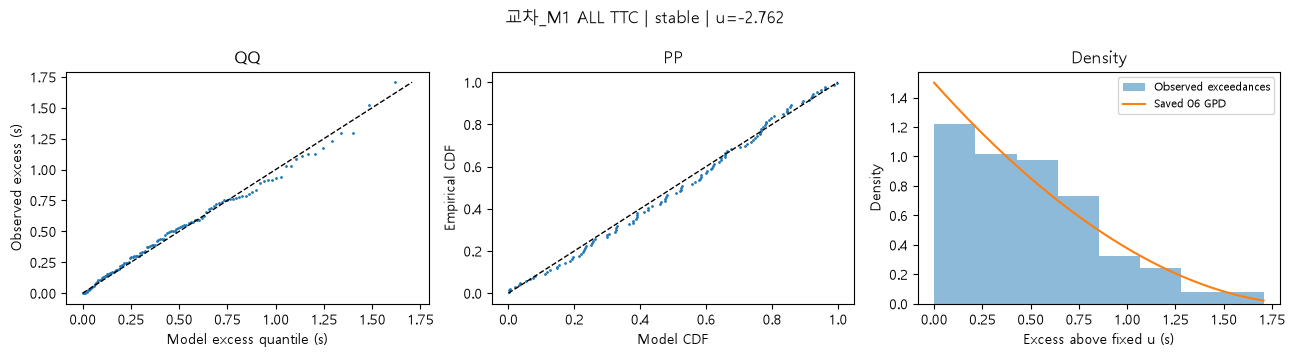

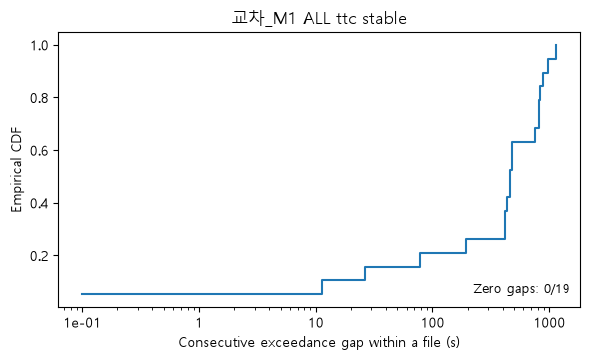

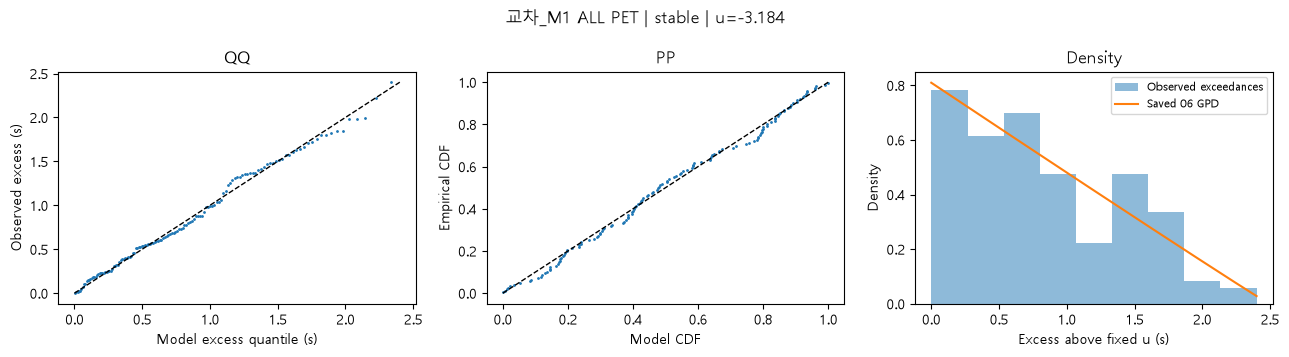

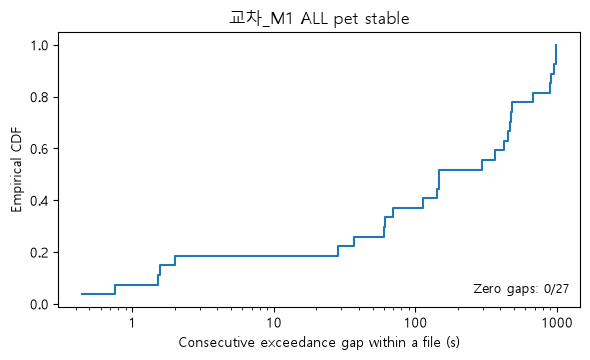

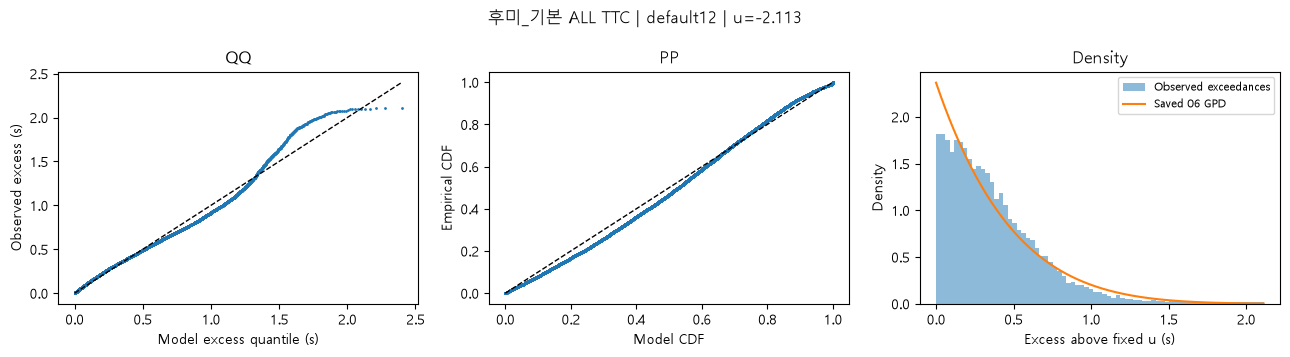

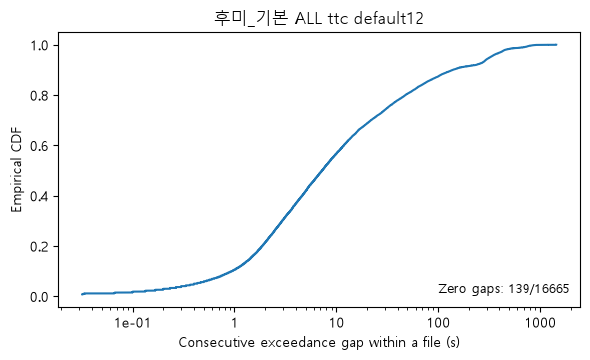

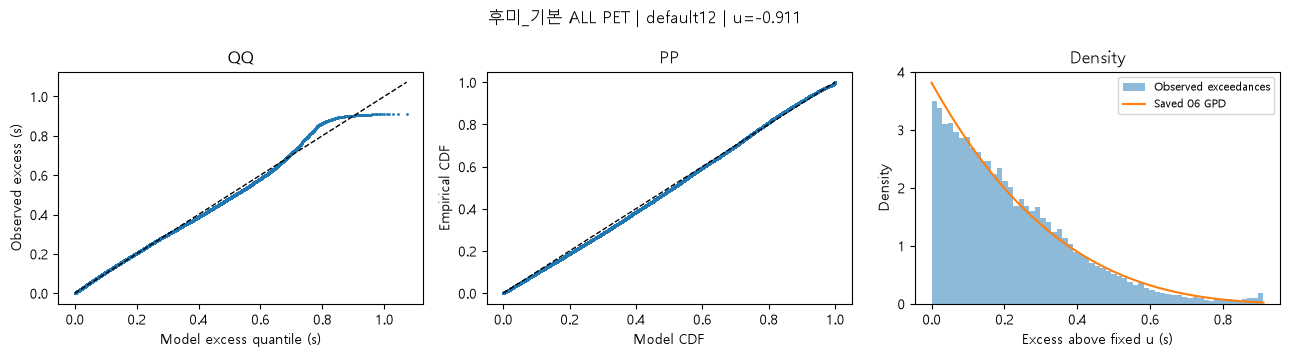

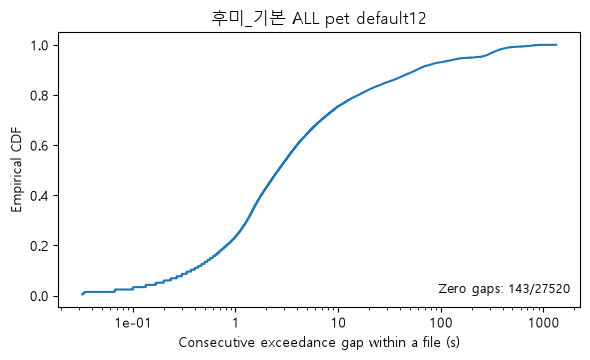

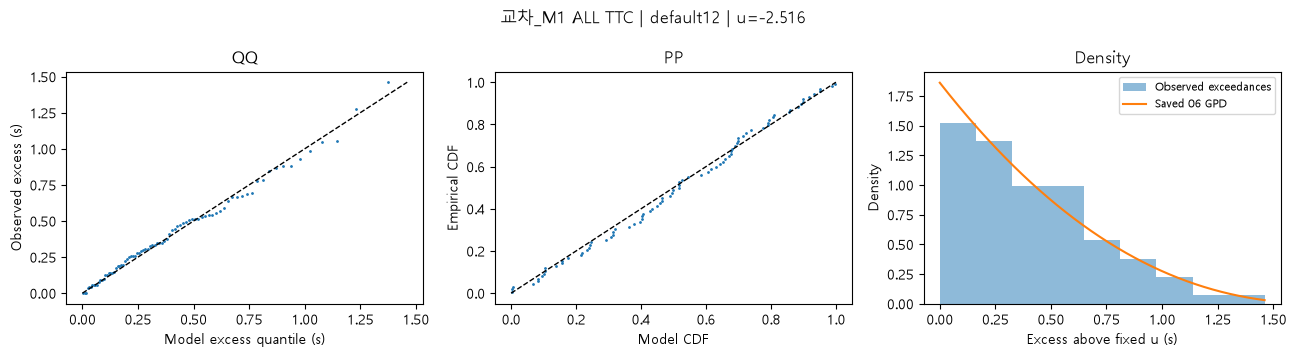

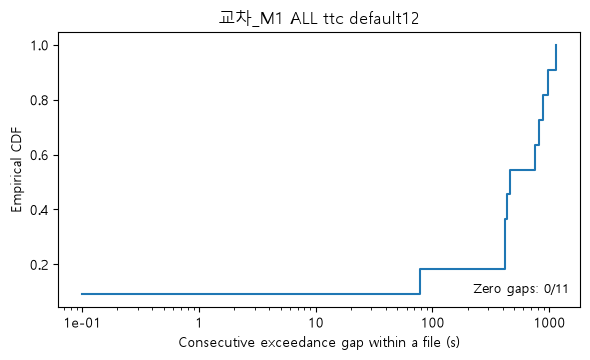

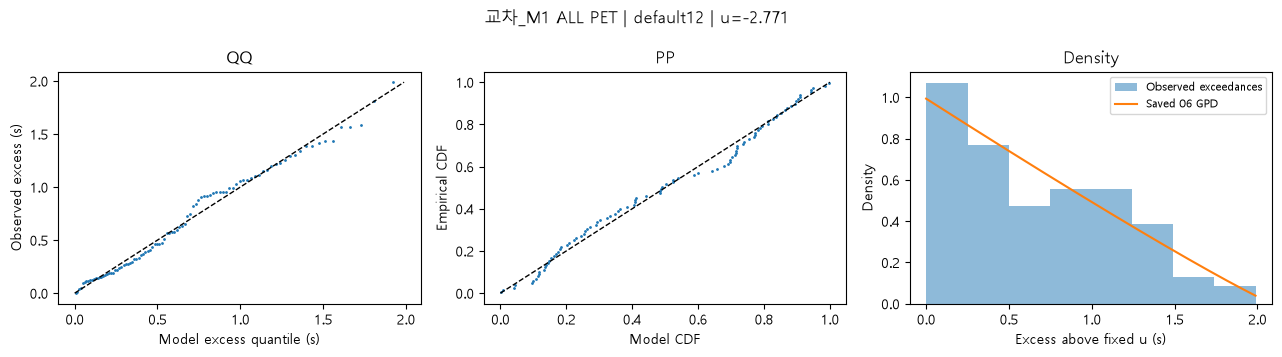

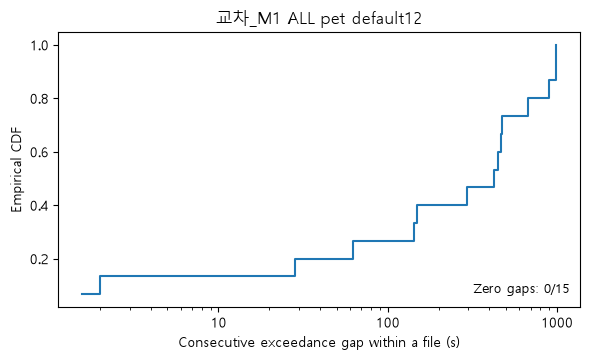

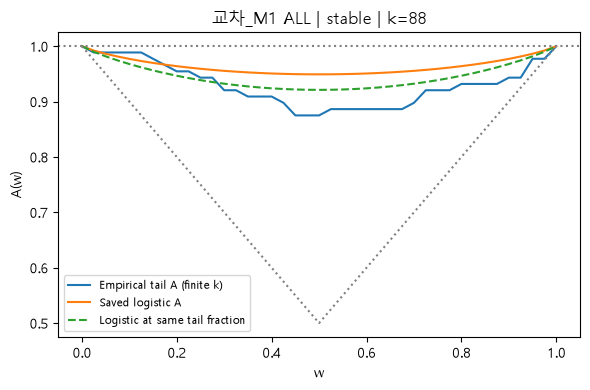

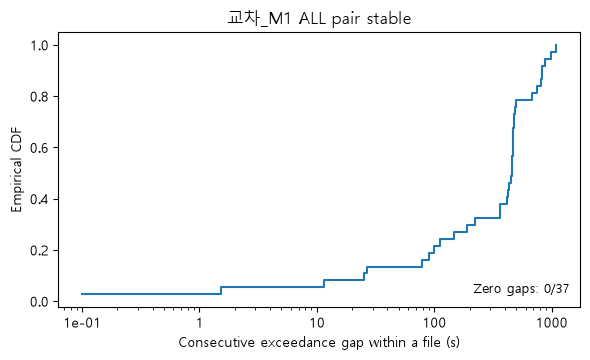

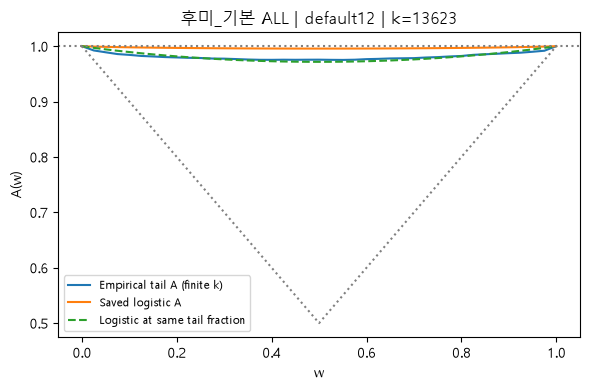

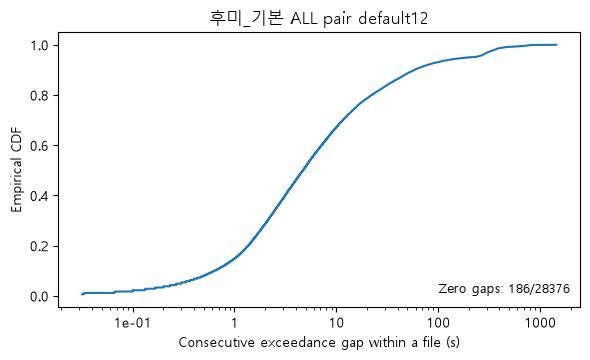

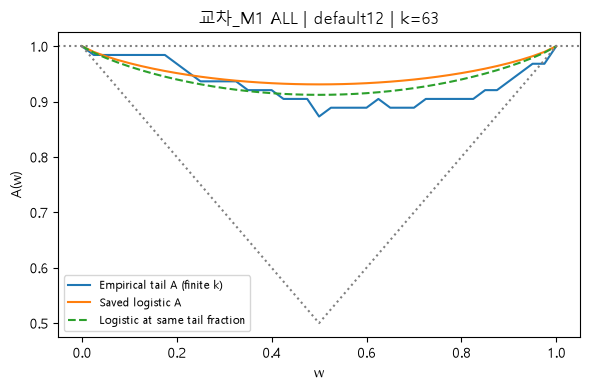

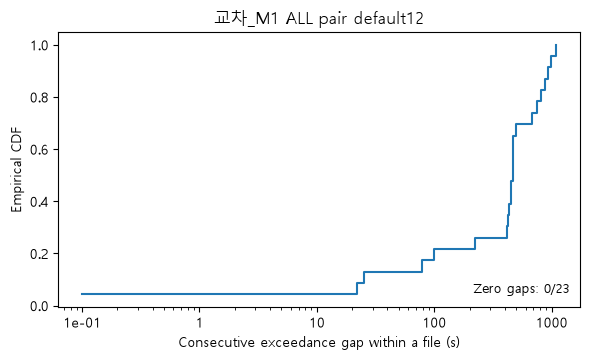

threshold_set  status                    
default12      boundary_estimate_excluded     5
               ok                            61
               too_few                       57
stable         boundary_estimate_excluded     2
               no_stable_region              18
               no_stable_threshold           13
               ok                            33
               too_few_for_stability         57
Name: rows, dtype: int64

,xi_below_minus_half,boundary_estimate,boundary_estimate_reason,interval_interpretation,seconds,level_negated,level_source,n,n_exceed,observed_min_seconds,...,status,observed_count,model_conditional,observed_conditional,model_all_finite,observed_all_finite,threshold_set,유형,지점,지표
0,False,False,,,1.500000,-1.500000,configured,671,115,1.054855,...,ok,4.0,0.044493,0.034783,0.007626,0.005961,stable,교차_M1,ALL,ttc
1,False,False,,,1.000000,-1.000000,configured,671,115,1.054855,...,outside_observed_range,NaN,NaN,NaN,NaN,NaN,stable,교차_M1,ALL,ttc
2,False,False,,,0.500000,-0.500000,configured,671,115,1.054855,...,outside_observed_range,NaN,NaN,NaN,NaN,NaN,stable,교차_M1,ALL,ttc
3,False,False,,,2.571180,-2.571180,observed_tail_quantile,671,115,1.054855,...,ok,86.0,0.740026,0.747826,0.126830,0.128167,stable,교차_M1,ALL,ttc
4,False,False,,,2.324446,-2.324446,observed_tail_quantile,671,115,1.054855,...,ok,58.0,0.474450,0.504348,0.081314,0.086438,stable,교차_M1,ALL,ttc
5,False,False,,,2.016621,-2.016621,observed_tail_quantile,671,115,1.054855,...,ok,29.0,0.241807,0.252174,0.041442,0.043219,stable,교차_M1,ALL,ttc
6,False,False,,,1.500000,-1.500000,configured,783,134,0.782593,...,ok,13.0,0.103188,0.097015,0.017659,0.016603,stable,교차_M1,ALL,pet
7,False,False,,,1.000000,-1.000000,configured,783,134,0.782593,...,ok,2.0,0.014770,0.014925,0.002528,0.002554,stable,교차_M1,ALL,pet
8,False,False,,,0.500000,-0.500000,configured,783,134,0.782593,...,outside_observed_range,NaN,NaN,NaN,NaN,NaN,stable,교차_M1,ALL,pet
9,False,False,,,2.824748,-2.824748,observed_tail_quantile,783,134,0.782593,...,ok,100.0,0.730716,0.746269,0.125052,0.127714,stable,교차_M1,ALL,pet


,threshold_set,유형,지점,지표,xi_below_minus_half,boundary_estimate,boundary_estimate_reason,interval_interpretation,n_tail,n_vehicle_ids_complete,...,n_gaps,n_sessions_with_tail,gap_min_s,gap_p25_s,gap_p50_s,gap_p75_s,gap_p95_s,gap_max_s,n_zero_gaps,gap_figure
0,stable,교차_M1,ALL,ttc,False,False,,,115,115,...,19,96,0.100000,303.412000,465.653000,822.087500,1000.314100,1149.697000,0,figures/stable_교차_M1_ALL_ttc_gaps.png
1,stable,교차_M1,ALL,pet,False,False,,,134,134,...,27,107,0.443601,48.749686,148.469391,476.430464,980.679420,992.727568,0,figures/stable_교차_M1_ALL_pet_gaps.png
2,default12,후미_기본,ALL,ttc,False,False,,,17418,17418,...,16665,753,0.000000,2.369000,7.274000,31.932000,321.757200,1445.275000,139,figures/default12_후미_기본_ALL_ttc_gaps.png
3,default12,후미_기본,ALL,pet,False,False,,,28288,28288,...,27520,768,0.000000,1.068000,2.603000,9.643000,213.450500,1336.765000,143,figures/default12_후미_기본_ALL_pet_gaps.png
4,default12,교차_M1,ALL,ttc,False,False,,,81,81,...,11,70,0.100000,418.210500,465.265000,848.304000,1066.706500,1149.697000,0,figures/default12_교차_M1_ALL_ttc_gaps.png
5,default12,교차_M1,ALL,pet,False,False,,,94,94,...,15,79,1.564275,102.467128,427.379868,573.917181,990.564723,992.727568,0,figures/default12_교차_M1_ALL_pet_gaps.png
6,stable,교차_M1,ALL,pair,False,False,,,183,183,...,37,146,0.100000,148.469391,456.421229,484.337000,897.588000,1097.585190,0,figures/stable_교차_M1_ALL_pair_gaps.png
7,default12,후미_기본,ALL,pair,False,False,,,29146,29146,...,28376,770,0.000000,1.702000,4.705000,15.581250,206.722000,1445.275000,186,figures/default12_후미_기본_ALL_pair_gaps.png
8,default12,교차_M1,ALL,pair,False,False,,,129,129,...,23,106,0.100000,318.837326,465.265000,715.112226,978.935545,1097.585190,0,figures/default12_교차_M1_ALL_pair_gaps.png
9,stable,후미_기본,A,ttc,False,False,,,310,310,...,270,40,0.033000,6.063750,55.786500,280.784750,685.236400,1445.275000,0,NaN


적합도·의존 진단 경과: 0.31분


In [9]:
if current_settings() != loaded_settings:
    raise ValueError("입력 로드 뒤 설정이 바뀌었습니다. 설정 이후부터 차례로 재실행하세요.")
diagnostic_started = time.perf_counter()
diagnostic_results = run_diagnostics(kinds, UNIVARIATE, BIVARIATE)
diagnostic_seconds = time.perf_counter() - diagnostic_started
display(diagnostic_results["diagnostic_status"].groupby(["threshold_set", "status"]).size().rename("rows"))
display(diagnostic_results["exceedance_comparison"].head(20))
display(diagnostic_results["dependence_summary"].head(20))
print(f"적합도·의존 진단 경과: {diagnostic_seconds / 60:.2f}분")

## 8. 파일 부트스트랩 함수
지점 층에서는 그 지점의 모든 완료 파일을 복원추출합니다. ALL은 각 지점 안에서 원래 파일 수만큼 뽑습니다.
추출 횟수는 파일 가중치이며 **사건 없는 파일과 관측시간에도 같은 횟수**를 적용합니다.
σ·ξ(이변량은 α도)만 다시 적합하고 u를 고정합니다. 표본수·초과비율은 매번 다시 셉니다.
0초 조건부 확률과 시간당 값의 2.5·97.5 백분위를 06 구간과 나란히 둡니다.
06 구간은 파일 추출 변동을 포함하지 않은 점근 정규 모의추출 구간입니다.
ξ<−0.5에서는 점근(정규) 근사가 약하므로 세션 부트스트랩 구간을 우선 봅니다.
끝점 근처라 세션 구간도 불안정할 수 있으며, ξ<−0.5 또는 경계 추정 행의 폭 비율은 비워 둡니다.
두 구간 중 어느 쪽이든 한쪽 끝이 0(모형 끝점이 0초에 못 미친 경우) 또는 α=1 경계(설정값 이상)에 닿으면 두 구간의 폭을 비교하지 않습니다.
세션 구간도 모든 경우에 더 넓어야 하는 것은 아닙니다.

실패한 적합은 0으로 채우지 않고 반복별 상태에 남깁니다. 성공 반복의 구간은 `conditional_on_success`로 표시합니다.
초과 30개 미만 실패 비율이 10%를 넘으면 경고합니다. 실패 반복을 뺀 구간은 편향될 수 있습니다.
폭이 수치 정밀도 허용치 안에서 0인 구간은 `degenerate_interval`로 표시합니다. 확률 0이 모형 끝점에서 나왔어도 불확실성이 없다는 뜻은 아닙니다.
경계 추정을 설정으로 포함했다면 구간 옆의 “해석 불가(경계)”를 확인하세요.
한 지점의 파일이 1개뿐이면 그 지점의 파일 변동을 추정할 수 없어 부트스트랩 대상에서 제외합니다.
95%는 명목 수준이며 작은 파일 수·B·끝점·모형 오지정 때문에 실제 포함률을 보장하지 않습니다.
같은 파일 안의 의존을 보존하지만 날짜/지점 사이 의존, 임계값 선택 불확실성은 포함하지 않습니다.

In [10]:
def weighted_gpd_nll(theta, z, weights):
    log_sigma, xi = theta
    if not np.isfinite(theta).all() or xi <= -1 or abs(log_sigma) > 700:
        return np.inf
    sigma = math.exp(log_sigma)
    if abs(xi) < 1e-8:
        return weights.sum() * log_sigma + np.dot(weights, z) / sigma
    support = 1 + xi * z / sigma
    if np.any(support <= 0):
        return np.inf
    return weights.sum() * log_sigma + (1 + 1 / xi) * np.dot(weights, np.log(support))


def weighted_bgp_nll(theta, x, y, ux, uy, zeta_x, zeta_y, weights):
    try:
        sx, xx, sy, xy, a = unpack(theta)
        if xx <= -1 or xy <= -1 or not 0 < a <= 1 or not np.isfinite(theta).all():
            return np.inf
        mx, my = margin_terms(x, ux, sx, xx, zeta_x), margin_terms(y, uy, sy, xy, zeta_y)
        if mx is None or my is None:
            return np.inf
        z1, ld1, e1 = mx
        z2, ld2, e2 = my
        lz1, lz2 = np.log(z1), np.log(z2)
        lp1, lp2 = -lz1 / a, -lz2 / a
        ls = np.logaddexp(lp1, lp2)
        lv = a * ls
        lv1 = lp1 - ls + lv - lz1
        lv2 = lp2 - ls + lv - lz2
        lv12 = ((math.log1p(-a) - math.log(a)) if a < 1 else -np.inf) + lp1 - ls + lp2 - ls + lv - lz1 - lz2
        ll = -np.exp(lv)
        ll += np.where(e1 & ~e2, lv1 + ld1, 0)
        ll += np.where(~e1 & e2, lv2 + ld2, 0)
        ll += np.where(e1 & e2, np.logaddexp(lv1 + lv2, lv12) + ld1 + ld2, 0)
        value = -np.dot(weights, ll)
        return float(value) if np.isfinite(value) else np.inf
    except (OverflowError, ValueError, ZeroDivisionError):
        return np.inf


def refit_point(objective, start, args):
    # Warm start from saved 06 point; no Hessian or asymptotic simulations.
    best = None
    starts = [np.asarray(start, float).copy()]
    # Second start is a check against a local optimum, without changing the likelihood.
    second = starts[0].copy()
    second[-1] = 0.1 if len(second) == 2 else 0.0
    starts.append(second)
    for initial in starts:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", RuntimeWarning)
            result = minimize(objective, initial, args=args, method="Nelder-Mead",
                              options={"xatol": 1e-7, "fatol": 1e-8, "maxiter": 4000 if len(initial) == 2 else 8000})
        if result.success and np.isfinite(result.fun) and (best is None or result.fun < best.fun):
            best = result
    return None if best is None else best.x


def draw_file_counts(sessions, rng):
    counts = np.zeros(len(sessions), dtype=int)
    for positions in sessions.groupby("site", sort=True).indices.values():
        positions = np.asarray(positions)
        np.add.at(counts, rng.choice(positions, size=len(positions), replace=True), 1)
    return counts


def prepare_bootstrap(part, sessions, row, mode):
    sessions = sessions.reset_index(drop=True)
    ids = pd.Index(sessions.session_key).get_indexer(part.session_key)
    if np.any(ids < 0):
        raise ValueError("부트스트랩 사건의 파일이 없습니다.")
    payload = dict(sessions=sessions, row=dict(row), mode=mode)
    if mode == "univariate":
        col = "x" if row["지표"] == "ttc" else "y"
        v = part[col].to_numpy(float)
        mask = np.isfinite(v)
        payload.update(values=v[mask], ids=ids[mask])
    else:
        xy = part[["x", "y"]].to_numpy(float)
        mask = np.isfinite(xy).all(axis=1)
        payload.update(values=xy[mask], ids=ids[mask])
    return payload


def bootstrap_once(payload, counts):
    row, values = payload["row"], payload["values"]
    hours = float(np.dot(counts, payload["sessions"].hours))
    ew = counts[payload["ids"]]
    keep = ew > 0
    values, ew = values[keep], ew[keep]
    common = dict(hours=hours, n=int(ew.sum()), n_files_drawn=int(counts.sum()),
                  n_distinct_files=int(np.sum(counts > 0)))
    if not np.isfinite(hours) or hours <= 0:
        return {**common, "status": "invalid_hours"}
    if payload["mode"] == "univariate":
        u = row["threshold"]
        mask = values > u
        z, weights = values[mask] - u, ew[mask]
        ne = int(weights.sum())
        common.update(n_exceed=ne, threshold=u)
        if ne < MIN_EXCEEDANCES:
            return {**common, "status": "too_few"}
        theta = refit_point(weighted_gpd_nll, [math.log(row["sigma"]), row["xi"]], (z, weights))
        if theta is None:
            return {**common, "status": "fit_failed"}
        p = conditional_boundary_prob(u, math.exp(theta[0]), theta[1])
        if not np.isfinite(p) or not 0 <= p <= 1:
            return {**common, "status": "invalid_probability"}
        return {**common, "status": "ok", "p_boundary_given_exceed": p,
                "per_hour": ne * p / hours, "sigma": math.exp(theta[0]), "xi": theta[1]}
    ux, uy = row["threshold_x"], row["threshold_y"]
    x, y = values[:, 0], values[:, 1]
    ex, ey = x > ux, y > uy
    nex, ney, n = int(ew[ex].sum()), int(ew[ey].sum()), int(ew.sum())
    common.update(n_pairs=n, n_exceed_x=nex, n_exceed_y=ney, threshold_x=ux, threshold_y=uy)
    if min(nex, ney) < MIN_EXCEEDANCES or max(nex, ney) >= n:
        return {**common, "status": "too_few"}
    zx, zy = nex / n, ney / n
    tail = ex | ey
    # All double-censored rows have exactly the same likelihood contribution.
    weights = np.r_[ew[tail], ew[~tail].sum()]
    x, y = np.r_[x[tail], ux], np.r_[y[tail], uy]
    positive = weights > 0
    x, y, weights = x[positive], y[positive], weights[positive]
    a = row["alpha"]
    # alpha=1 has no finite logit; use the original 06 starting logit in that case.
    logit_start = math.log(a / (1 - a)) if 0 < a < 1 else 2.0
    start = [math.log(row["sigma_x"]), row["xi_x"], math.log(row["sigma_y"]), row["xi_y"], logit_start]
    theta = refit_point(weighted_bgp_nll, start, (x, y, ux, uy, zx, zy, weights))
    if theta is None:
        return {**common, "status": "fit_failed"}
    por = bgp_boundary(theta, ux, uy, zx, zy)[0]
    if not np.isfinite(por) or not 0 <= por <= 1:
        return {**common, "status": "invalid_probability"}
    return {**common, "status": "ok", "alpha": unpack(theta)[4], "p_or": por, "per_hour_or": n * por / hours}


def seeded_rng(identity, seed):
    digest = hashlib.sha256(json.dumps(identity, sort_keys=True, ensure_ascii=False).encode()).digest()
    return np.random.default_rng(np.random.SeedSequence([seed, *np.frombuffer(digest[:16], dtype="<u4").tolist()]))


def bootstrap_replicates(payload, b, rng, start_index=0):
    rows = []
    for index in range(start_index, start_index + b):
        counts = draw_file_counts(payload["sessions"], rng)
        result = bootstrap_once(payload, counts)
        rows.append({"replicate": index, **result})
    return pd.DataFrame(rows)


def bootstrap_summary(draws, row, mode):
    success = draws.loc[draws.status.eq("ok")]
    flags = fit_flags(row, mode)
    xi_draws = success["xi"].dropna() if "xi" in success else pd.Series(dtype=float)
    xi_draws = xi_draws[np.isfinite(xi_draws)]
    boundary_field = "xi" if mode == "univariate" else "alpha"
    boundary_draws = success[boundary_field].dropna() if boundary_field in success else pd.Series(dtype=float)
    boundary_draws = boundary_draws[np.isfinite(boundary_draws)]
    boundary_mask = boundary_draws.le(BOUNDARY_XI) if mode == "univariate" else boundary_draws.ge(BOUNDARY_ALPHA)
    count_fields = ["n_exceed"] if mode == "univariate" else ["n_exceed_x", "n_exceed_y"]
    below_min = (draws[count_fields].lt(MIN_EXCEEDANCES).any(axis=1) & draws.status.eq("too_few")) if set(count_fields).issubset(draws) else None
    below_fraction = float(below_min.mean()) if below_min is not None and len(draws) else np.nan
    common = {**flags, "B": len(draws), "B_success": len(success), "B_failed": len(draws) - len(success),
              "success_fraction": len(success) / len(draws) if len(draws) else np.nan,
              "bootstrap_xi_below_minus_half_fraction": float(xi_draws.lt(-0.5).mean()) if len(xi_draws) else np.nan,
              "bootstrap_boundary_fraction": float(boundary_mask.mean()) if len(boundary_draws) else np.nan,
              "bootstrap_boundary_scope": "xi_only" if mode == "univariate" else "alpha_only; marginal_xi_not_recorded",
              "below_min_exceedances_fraction": below_fraction,
              "warning": f"초과 {MIN_EXCEEDANCES}개 미만 실패가 10% 초과: 성공 반복만 쓴 구간은 편향될 수 있습니다." if below_fraction > 0.1 else "",
              "status": "all_success" if len(success) == len(draws) else "conditional_on_success"}
    if len(success) < 2:
        common["status"] = "insufficient_success"
    def ratio(value, denominator):
        return value / denominator if np.isfinite(denominator) and denominator > 0 else np.nan
    if not np.isfinite(row.get("hours", np.nan)) or row["hours"] <= 0:
        common["status"] = "invalid_saved_hours"
    if mode == "univariate":
        ne, hours = row["n_exceed"], row["hours"]
        metrics = {"p_boundary_given_exceed": (row.get("p_boundary_given_exceed", np.nan), ratio(row.get("expected_low", np.nan), ne), ratio(row.get("expected_high", np.nan), ne)),
                   "per_hour": (ratio(row.get("expected_boundary_events", np.nan), hours), ratio(row.get("expected_low", np.nan), hours), ratio(row.get("expected_high", np.nan), hours))}
    else:
        metrics = {"alpha": (row["alpha"], row.get("alpha_low", np.nan), row.get("alpha_high", np.nan)),
                   "per_hour_or": (ratio(row.get("expected_or", np.nan), row["hours"]), ratio(row.get("expected_or_low", np.nan), row["hours"]), ratio(row.get("expected_or_high", np.nan), row["hours"]))}
    output = []
    for metric, (point, low06, high06) in metrics.items():
        valid = success[metric].to_numpy(float) if metric in success else np.array([])
        valid = valid[np.isfinite(valid)]
        lo, hi = np.quantile(valid, [0.025, 0.975]) if len(valid) >= 2 else (np.nan, np.nan)
        zero_fraction = float(np.mean(valid == 0)) if metric != "alpha" and len(valid) else np.nan
        degenerate = len(valid) >= 2 and np.isclose(hi, lo, rtol=1e-9, atol=1e-12)
        status = common["status"]
        if degenerate and status != "invalid_saved_hours":
            status = "degenerate_interval"
        reasons = []
        if flags["boundary_estimate"]:
            reasons.append("boundary_estimate")
        if flags["xi_below_minus_half"]:
            reasons.append("xi_below_minus_half")
        if not np.isfinite(lo) or not np.isfinite(hi):
            reasons.append("insufficient_success")
        elif degenerate:
            reasons.append("degenerate_interval")
        if metric != "alpha" and (lo == 0 or low06 == 0):
            reasons.append("interval_at_zero_endpoint:구간 끝이 0(끝점 질량)에 닿아 폭 비교 불가")
        if metric == "alpha" and (hi >= BOUNDARY_ALPHA or high06 >= BOUNDARY_ALPHA):
            reasons.append("interval_at_alpha_boundary:구간 끝이 α 경계에 닿아 폭 비교 불가")
        if not np.isfinite(low06) or not np.isfinite(high06):
            reasons.append("asymptotic06_unavailable")
        elif high06 <= low06:
            reasons.append("asymptotic06_nonpositive_width")
        if common["status"] == "invalid_saved_hours":
            reasons.append("invalid_saved_hours")
        interpretation = flags["interval_interpretation"]
        if status == "degenerate_interval" and not interpretation:
            interpretation = "퇴화 구간: 성공 반복의 백분위 폭이 수치 허용치 안에서 0"
        output.append({**common, "status": status, "interval_interpretation": interpretation,
                       "metric": metric, "point06": point, "asymptotic06_low": low06,
                       "asymptotic06_high": high06, "bootstrap_low": lo, "bootstrap_high": hi,
                       "bootstrap_zero_fraction": zero_fraction,
                       "asymptotic06_status": "available" if np.isfinite(low06) and np.isfinite(high06) else "unavailable",
                       "width_ratio": (hi - lo) / (high06 - low06) if not reasons else np.nan,
                       "width_ratio_reason": ";".join(reasons)})
    return pd.DataFrame(output)

## 9. 대상 선택과 실제 속도 예측
각 대상에서 먼저 2회만 실행해 남은 시간을 예측합니다. 이 반복은 최종 B에 포함합니다. 30분을 넘으면 B·지점 수를 줄일 수 있습니다. 이 예측은 기기·최적화 난이도에 따라 달라집니다.

In [11]:
def select_jobs(uni, bi):
    jobs, skipped = [], []
    for mode, tables, qualify in (("univariate", uni, eligible_uni), ("bivariate", bi, eligible_bi)):
        for name, table in tables.items():
            if mode == "bivariate" and name not in uni:
                continue
            for kind in KINDS:
                candidates = []
                for row in table.loc[table["유형"].eq(kind)].to_dict("records"):
                    reason = qualify(row)
                    identity = dict(mode=mode, threshold_set=name, 유형=kind, 지점=row["지점"], 지표=row.get("지표", "pair"))
                    if reason != "ok":
                        skipped.append({**identity, **fit_flags(row, mode), "status": reason})
                        continue
                    candidates.append((row, identity))
                allowed = None
                if BOOTSTRAP_SITES is None and TOP_SITE_COUNT is not None:
                    scores = {}
                    for row, _ in candidates:
                        if row["지점"] != "ALL":
                            label = row["지표"] if mode == "univariate" else "pair"
                            score = row["n_exceed"] if mode == "univariate" else min(row["n_exceed_x"], row["n_exceed_y"])
                            scores.setdefault(label, {})[row["지점"]] = score
                    allowed = {label: {"ALL", *sorted(sites, key=lambda s: (-sites[s], s))[:TOP_SITE_COUNT]}
                               for label, sites in scores.items()}
                for row, identity in candidates:
                    chosen = row["지점"] in BOOTSTRAP_SITES if BOOTSTRAP_SITES is not None else allowed is None or row["지점"] in allowed.get(identity["지표"], {"ALL"})
                    if not chosen:
                        skipped.append({**identity, **fit_flags(row, mode), "status": "not_selected_for_bootstrap"})
                        continue
                    jobs.append({"identity": identity, "row": row, "mode": mode})
    return jobs, skipped


def calibrate_jobs(jobs, kinds, sessions, skipped):
    output, estimates = [], []
    for job in jobs:
        identity, row, mode = job["identity"], job["row"], job["mode"]
        frame = sessions_for(sessions, row["지점"])
        sizes = frame.groupby("site").size()
        if sizes.empty or (sizes < 2).any():
            skipped.append({**identity, "status": "insufficient_sessions"})
            continue
        payload = prepare_bootstrap(part_for(kinds, row["유형"], row["지점"]), frame, row, mode)
        rng = seeded_rng(identity, RANDOM_SEED)
        b = B_UNIVARIATE if mode == "univariate" else B_BIVARIATE
        started = time.perf_counter()
        pilot = bootstrap_replicates(payload, min(2, b), rng)
        elapsed = time.perf_counter() - started
        estimate = elapsed / len(pilot) * b
        estimates.append({**identity, "B": b, "n_sessions": len(frame), "pilot_seconds": elapsed,
                          "pilot_success": int(pilot.status.eq("ok").sum()), "estimated_seconds": estimate})
        print(identity, f"B={b}, 예상 {estimate / 60:.2f}분, pilot {pilot.status.value_counts().to_dict()}")
        output.append({**job, "payload": payload, "rng": rng, "pilot": pilot, "B": b})
    columns = ["mode", "threshold_set", "유형", "지점", "지표", "B", "n_sessions",
               "pilot_seconds", "pilot_success", "estimated_seconds"]
    return output, pd.DataFrame(estimates, columns=columns)

### 9-1. 대상별 pilot 실행
현재 설정의 대상과 제외 이유를 저장하고, 파일 부트스트랩 2회 속도로 전체 계산시간을 추정합니다.

In [12]:
if current_settings() != loaded_settings:
    raise ValueError("입력 로드 뒤 설정이 바뀌었습니다. 설정 이후부터 차례로 재실행하세요.")
jobs, bootstrap_skipped = select_jobs(UNIVARIATE, BIVARIATE)
active_jobs, runtime_estimates = calibrate_jobs(jobs, kinds, sessions, bootstrap_skipped)
calibrated_settings = current_settings()
save_csv(pd.DataFrame(bootstrap_skipped, columns=["mode", "threshold_set", "유형", "지점", "지표", "status",
    "xi_below_minus_half", "boundary_estimate", "boundary_estimate_reason", "interval_interpretation"]), "bootstrap_skipped.csv")
save_csv(runtime_estimates, "runtime_estimates.csv")
bootstrap_estimated_s = runtime_estimates.estimated_seconds.sum() if len(runtime_estimates) else 0.0
estimated_total_minutes = (input_seconds + diagnostic_seconds + bootstrap_estimated_s) / 60
print(f"현재 설정의 입력+진단+부트스트랩 전체 예상: {estimated_total_minutes:.1f}분 (목표 {RUNTIME_TARGET_MINUTES}분; 잔여 결과 저장 시간 별도)")
print("목표 초과: B 또는 대상 지점 수를 줄이고 설정 이후부터 재실행하세요." if estimated_total_minutes > RUNTIME_TARGET_MINUTES else "현재 예측은 목표 시간 안입니다.")
print("예측은 2회 측정에 근거한 근사이며 전체 실행시간을 보장하지 않습니다.")
display(runtime_estimates)

{'mode': 'univariate', 'threshold_set': 'stable', '유형': '후미_기본', '지점': 'I', '지표': 'ttc'} B=300, 예상 0.02분, pilot {'ok': 2}
{'mode': 'univariate', 'threshold_set': 'stable', '유형': '후미_기본', '지점': 'S', '지표': 'pet'} B=300, 예상 0.02분, pilot {'ok': 2}
{'mode': 'univariate', 'threshold_set': 'stable', '유형': '교차_M1', '지점': 'ALL', '지표': 'ttc'} B=300, 예상 0.02분, pilot {'ok': 2}
{'mode': 'univariate', 'threshold_set': 'stable', '유형': '교차_M1', '지점': 'ALL', '지표': 'pet'} B=300, 예상 0.02분, pilot {'ok': 2}
{'mode': 'univariate', 'threshold_set': 'default12', '유형': '후미_기본', '지점': 'ALL', '지표': 'ttc'} B=300, 예상 0.16분, pilot {'ok': 2}
{'mode': 'univariate', 'threshold_set': 'default12', '유형': '후미_기본', '지점': 'ALL', '지표': 'pet'} B=300, 예상 0.21분, pilot {'ok': 2}
{'mode': 'univariate', 'threshold_set': 'default12', '유형': '후미_기본', '지점': 'S', '지표': 'ttc'} B=300, 예상 0.02분, pilot {'ok': 2}
{'mode': 'univariate', 'threshold_set': 'default12', '유형': '후미_기본', '지점': 'S', '지표': 'pet'} B=300, 예상 0.03분, pilot {'ok': 2}
{'mo

,mode,threshold_set,유형,지점,지표,B,n_sessions,pilot_seconds,pilot_success,estimated_seconds
0,univariate,stable,후미_기본,I,ttc,300,40,0.007649,2,1.147305
1,univariate,stable,후미_기본,S,pet,300,40,0.008194,2,1.229160
2,univariate,stable,교차_M1,ALL,ttc,300,800,0.006669,2,1.000365
3,univariate,stable,교차_M1,ALL,pet,300,800,0.007305,2,1.095810
4,univariate,default12,후미_기본,ALL,ttc,300,800,0.065565,2,9.834810
5,univariate,default12,후미_기본,ALL,pet,300,800,0.082782,2,12.417330
6,univariate,default12,후미_기본,S,ttc,300,40,0.008494,2,1.274130
7,univariate,default12,후미_기본,S,pet,300,40,0.010081,2,1.512090
8,univariate,default12,교차_M1,ALL,ttc,300,800,0.006499,2,0.974910
9,univariate,default12,교차_M1,ALL,pet,300,800,0.007965,2,1.194765


## 10. 부트스트랩 실행
위 예측을 확인한 뒤 실행합니다. 대상마다 반복별 결과와 구간을 바로 저장해 일부 실패도 추적할 수 있습니다.

In [13]:
if current_settings() != calibrated_settings:
    raise ValueError("pilot 이후 설정이 바뀌었습니다. 설정 이후부터 차례로 재실행하세요.")
bootstrap_started = time.perf_counter()
bootstrap_summaries = []
for job in active_jobs:
    identity = job["identity"]
    # Re-running this cell reproduces the same draws, including the retained pilot.
    job_rng = seeded_rng(identity, RANDOM_SEED)
    for _ in range(len(job["pilot"])):
        draw_file_counts(job["payload"]["sessions"], job_rng)
    draws = [job["pilot"]]
    done = len(job["pilot"])
    while done < job["B"]:
        batch = min(20, job["B"] - done)
        draws.append(bootstrap_replicates(job["payload"], batch, job_rng, done))
        done += batch
        print(identity, f"{done}/{job['B']}")
    replicates = pd.concat(draws, ignore_index=True)
    stem = "_".join(str(identity[k]) for k in ("mode", "threshold_set", "유형", "지점", "지표"))
    save_csv(replicates.assign(**identity), f"bootstrap_replicates/{stem}.csv")
    summary = bootstrap_summary(replicates, job["row"], job["mode"]).assign(**identity)
    bootstrap_summaries.append(summary)
    save_csv(pd.concat(bootstrap_summaries, ignore_index=True), "bootstrap_comparison.csv")
bootstrap_comparison = pd.concat(bootstrap_summaries, ignore_index=True) if bootstrap_summaries else pd.DataFrame(
    columns=["mode", "threshold_set", "유형", "지점", "지표", "metric", "B", "B_success", "B_failed", "status",
             "point06", "asymptotic06_low", "asymptotic06_high", "bootstrap_low", "bootstrap_high"])
save_csv(bootstrap_comparison, "bootstrap_comparison.csv")
bootstrap_seconds = time.perf_counter() - bootstrap_started
display(bootstrap_comparison)
print(f"pilot 이후 부트스트랩 경과: {bootstrap_seconds / 60:.2f}분")

{'mode': 'univariate', 'threshold_set': 'stable', '유형': '후미_기본', '지점': 'I', '지표': 'ttc'} 22/300
{'mode': 'univariate', 'threshold_set': 'stable', '유형': '후미_기본', '지점': 'I', '지표': 'ttc'} 42/300
{'mode': 'univariate', 'threshold_set': 'stable', '유형': '후미_기본', '지점': 'I', '지표': 'ttc'} 62/300
{'mode': 'univariate', 'threshold_set': 'stable', '유형': '후미_기본', '지점': 'I', '지표': 'ttc'} 82/300
{'mode': 'univariate', 'threshold_set': 'stable', '유형': '후미_기본', '지점': 'I', '지표': 'ttc'} 102/300
{'mode': 'univariate', 'threshold_set': 'stable', '유형': '후미_기본', '지점': 'I', '지표': 'ttc'} 122/300
{'mode': 'univariate', 'threshold_set': 'stable', '유형': '후미_기본', '지점': 'I', '지표': 'ttc'} 142/300
{'mode': 'univariate', 'threshold_set': 'stable', '유형': '후미_기본', '지점': 'I', '지표': 'ttc'} 162/300
{'mode': 'univariate', 'threshold_set': 'stable', '유형': '후미_기본', '지점': 'I', '지표': 'ttc'} 182/300
{'mode': 'univariate', 'threshold_set': 'stable', '유형': '후미_기본', '지점': 'I', '지표': 'ttc'} 202/300
{'mode': 'univariate', 'threshold_

,xi_below_minus_half,boundary_estimate,boundary_estimate_reason,interval_interpretation,B,B_success,B_failed,success_fraction,bootstrap_xi_below_minus_half_fraction,bootstrap_boundary_fraction,...,bootstrap_high,bootstrap_zero_fraction,asymptotic06_status,width_ratio,width_ratio_reason,mode,threshold_set,유형,지점,지표
0,False,False,,,300,300,0,1.000,0.000000,0.000000,...,0.002145,0.000000,available,0.872547,,univariate,stable,후미_기본,I,ttc
1,False,False,,,300,300,0,1.000,0.000000,0.000000,...,0.218526,0.000000,available,0.868501,,univariate,stable,후미_기본,I,ttc
2,False,False,,,300,300,0,1.000,0.000000,0.000000,...,0.002852,0.000000,available,1.060018,,univariate,stable,후미_기본,S,pet
3,False,False,,,300,300,0,1.000,0.000000,0.000000,...,0.493915,0.000000,available,1.039913,,univariate,stable,후미_기본,S,pet
4,False,False,,퇴화 구간: 성공 반복의 백분위 폭이 수치 허용치 안에서 0,300,300,0,1.000,0.113333,0.000000,...,0.000000,0.996667,available,NaN,degenerate_interval;interval_at_zero_endpoint:...,univariate,stable,교차_M1,ALL,ttc
5,False,False,,퇴화 구간: 성공 반복의 백분위 폭이 수치 허용치 안에서 0,300,300,0,1.000,0.113333,0.000000,...,0.000000,0.996667,available,NaN,degenerate_interval;interval_at_zero_endpoint:...,univariate,stable,교차_M1,ALL,ttc
6,False,False,,퇴화 구간: 성공 반복의 백분위 폭이 수치 허용치 안에서 0,300,300,0,1.000,0.633333,0.006667,...,0.000000,1.000000,available,NaN,degenerate_interval;interval_at_zero_endpoint:...,univariate,stable,교차_M1,ALL,pet
7,False,False,,퇴화 구간: 성공 반복의 백분위 폭이 수치 허용치 안에서 0,300,300,0,1.000,0.633333,0.006667,...,0.000000,1.000000,available,NaN,degenerate_interval;interval_at_zero_endpoint:...,univariate,stable,교차_M1,ALL,pet
8,False,False,,,300,300,0,1.000,0.000000,0.000000,...,0.000480,0.000000,available,1.424115,,univariate,default12,후미_기본,ALL,ttc
9,False,False,,,300,300,0,1.000,0.000000,0.000000,...,0.060685,0.000000,available,1.415357,,univariate,default12,후미_기본,ALL,ttc


pilot 이후 부트스트랩 경과: 10.95분


## 11. 결과 확인과 마무리
- `reproduction_audit.csv`: 저장 06과 표본·초과 수·임계값·관측시간이 일치했는지.
- `diagnostic_status.csv`, `diagnostic_points/`, `figures/`: 건너뛴 이유와 QQ·PP·밀도·Pickands 그림.
- `exceedance_comparison.csv`: 관측 범위 안 조건부/전체 초과비율 대조.
- `dependence_summary.csv`, `within_session_gaps.csv`: 차량 공유율과 파일 내 시간 간격의 전체 경험 분포.
- `bootstrap_comparison.csv`, `bootstrap_replicates/`: 06 점근 구간과 파일 구간, 성공/실패 수.
- `xi_below_minus_half`, `boundary_estimate`, `width_ratio_reason`: 점근 근사 주의·경계·폭 비교 생략 이유.
- `bootstrap_xi_below_minus_half_fraction`: 성공한 단변량 반복 중 ξ*<−0.5 비율(실패 반복 제외).
- `bootstrap_zero_fraction`: 확률·시간당 지표의 성공한 유한 반복 값 중 0인 비율입니다. 실패·결측은 분모에서 빼고, α에는 적용하지 않아 빈칸으로 둡니다.
- `bootstrap_boundary_fraction`: 성공 반복 중 단변량 ξ* 또는 이변량 α*의 경계 비율. 이변량 주변 ξ*는 저장하지 않아 포함하지 않습니다.
- `below_min_exceedances_fraction`: 전체 반복 중 초과 부족으로 실패한 비율. 실패를 뺀 구간의 편향에 주의합니다.
- `threshold_files.csv`, `threshold_sensitivity_links.csv`: 실제 읽은 기준과 06 임계값 민감도 원본 연결.

안정 후보가 없는 층은 민감도 표를 중심으로 검토하고, 해당 층의 구간을 임의로 채우지 않습니다.
QQ가 맞는다고 0초 외삽이 검증된 것은 아닙니다. 더 넓은 구간도 더 정확한 사고 예측이라는 뜻은 아닙니다.
부트스트랩 구간은 선택한 파일·임계값·모형에 조건부이며 다른 국가나 미관측 신호 조건에 일반화하지 않습니다.

In [14]:
if current_settings() != calibrated_settings:
    raise ValueError("계산 뒤 설정이 바뀌었습니다. 설정 이후부터 차례로 재실행하세요.")
run_meta.update(calibrated_settings)
run_meta.update(status="completed", finished_at_utc=datetime.now(timezone.utc).isoformat(),
                estimated_total_minutes=float(estimated_total_minutes), input_seconds=input_seconds, diagnostic_seconds=diagnostic_seconds,
                bootstrap_seconds_after_pilot=bootstrap_seconds, n_bootstrap_jobs=len(active_jobs),
                n_skipped_bootstrap_rows=len(bootstrap_skipped), n_reproduction_checks=len(audit))
save_json(run_meta, "run_metadata.json")
save_json(INPUT_MANIFEST, "input_manifest.json")
print("08 완료:", RUN_ID)
print("관측 꼬리 적합도와 조건부 불확실성만 보고합니다. 사고 예측 정확도는 평가하지 않았습니다.")

08 완료: 20260924T192132Z_4ee40b5c
관측 꼬리 적합도와 조건부 불확실성만 보고합니다. 사고 예측 정확도는 평가하지 않았습니다.
